IMPORT DATA

In [ ]:
# ============================================
# BƯỚC 0+1: Mount Drive + Lấy danh sách + Tải ảnh
# Cell độc lập, chạy được mà không cần cell cũ
# ============================================
import os, io
from tqdm import tqdm
from google.colab import drive
from googleapiclient.discovery import build
from google.colab import auth
from googleapiclient.http import MediaIoBaseDownload

# --- Mount Drive ---
drive.mount('/content/drive', force_remount=False)

# --- Xác thực Google Drive API ---
auth.authenticate_user()
from google.auth import default
creds, _ = default()
drive_service = build('drive', 'v3', credentials=creds)

# --- Hàm lấy toàn bộ file đệ quy ---
def get_all_files(folder_id, path=""):
    results  = drive_service.files().list(
        q=f"'{folder_id}' in parents and trashed=false",
        fields="files(id, name, mimeType)"
    ).execute()
    items    = results.get('files', [])
    all_files = []
    for item in items:
        current_path = f"{path}/{item['name']}"
        if item['mimeType'] == 'application/vnd.google-apps.folder':
            all_files += get_all_files(item['id'], current_path)
        else:
            all_files.append({
                'id'      : item['id'],
                'name'    : item['name'],
                'path'    : current_path,
                'mimeType': item['mimeType']
            })
    return all_files

ROOT_FOLDER_ID = '1pC8ziC36UiZV1OAYpdSQS4tJyrlfJi1A'
print("📂 Đang lấy danh sách file từ Drive...")
all_files = get_all_files(ROOT_FOLDER_ID)
print(f"✅ Tổng số file: {len(all_files)}")

# --- Tải về local ---
LOCAL_ROOT = '/content/snake_data'
os.makedirs(LOCAL_ROOT, exist_ok=True)

def download_to_local(file_info, local_root):
    local_path = os.path.join(local_root, file_info['path'].lstrip('/'))
    if os.path.exists(local_path):
        return 'skip'
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    try:
        request = drive_service.files().get_media(fileId=file_info['id'])
        buffer  = io.BytesIO()
        dl      = MediaIoBaseDownload(buffer, request)
        done    = False
        while not done:
            _, done = dl.next_chunk()
        buffer.seek(0)
        with open(local_path, 'wb') as f:
            f.write(buffer.read())
        return 'ok'
    except Exception as e:
        return f'error: {e}'

results = {'ok': 0, 'skip': 0, 'error': 0}
errors  = []

for f in tqdm(all_files, desc='Downloading'):
    status = download_to_local(f, LOCAL_ROOT)
    if status.startswith('error'):
        results['error'] += 1
        errors.append((f['path'], status))
    else:
        results[status] += 1

print(f"\n✅ Tải xong!")
print(f"   Mới tải : {results['ok']}")
print(f"   Đã có   : {results['skip']}")
print(f"   Lỗi     : {results['error']}")
if errors:
    print("\n⚠️  Các file lỗi (10 đầu):")
    for path, err in errors[:10]:
        print(f"   {path}: {err}")

import subprocess
out = subprocess.run(['du', '-sh', LOCAL_ROOT], capture_output=True, text=True)
print(f"\n📦 Dung lượng: {out.stdout.strip()}")

Mounted at /content/drive


📂 Đang lấy danh sách file từ Drive...
✅ Tổng số file: 4153


Downloading: 100%|██████████| 4153/4153 [54:05<00:00,  1.28it/s]


✅ Tải xong!
   Mới tải : 4153
   Đã có   : 0
   Lỗi     : 0

📦 Dung lượng: 1.7G	/content/snake_data


In [ ]:
# ============================================
# BƯỚC 2: Khám phá cấu trúc dữ liệu local
# Mục đích: xác nhận cấu trúc thư mục, tìm họ overlap
# ============================================
import os
from collections import defaultdict

LOCAL_ROOT = '/content/snake_data'

# --- Quét toàn bộ cấu trúc ---
# Giả định cấu trúc: LOCAL_ROOT / doc_status / ho / loai / anh.jpg
records = []  # list of dict

for doc_status in os.listdir(LOCAL_ROOT):
    doc_path = os.path.join(LOCAL_ROOT, doc_status)
    if not os.path.isdir(doc_path):
        continue
    for ho in os.listdir(doc_path):
        ho_path = os.path.join(doc_path, ho)
        if not os.path.isdir(ho_path):
            continue
        for loai in os.listdir(ho_path):
            loai_path = os.path.join(ho_path, loai)
            if not os.path.isdir(loai_path):
                continue
            for img in os.listdir(loai_path):
                if img.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                    records.append({
                        'path'      : os.path.join(loai_path, img),
                        'doc_status': doc_status,
                        'ho'        : ho,
                        'loai'      : loai,
                    })

import pandas as pd
df = pd.DataFrame(records)

print(f"📊 Tổng ảnh quét được: {len(df)}")
print(f"\n--- Cấu trúc doc_status ---")
print(df['doc_status'].value_counts().to_string())

print(f"\n--- Danh sách họ theo doc_status ---")
pivot = df.groupby(['ho', 'doc_status']).size().unstack(fill_value=0)
print(pivot.to_string())

print(f"\n--- Họ xuất hiện ở CẢ HAI nhóm (overlap) ---")
overlap_ho = pivot[(pivot > 0).all(axis=1)]
print(overlap_ho.to_string() if len(overlap_ho) > 0 else "Không có họ nào overlap")

print(f"\n--- Tổng số họ unique ---")
print(f"  Tất cả   : {df['ho'].nunique()}")
print(f"  Chỉ độc  : {df[df['doc_status'].str.contains('doc', case=False)]['ho'].nunique()}")
print(f"  Chỉ không độc: {df[~df['doc_status'].str.contains('doc', case=False)]['ho'].nunique()}")

📊 Tổng ảnh quét được: 4015

--- Cấu trúc doc_status ---
doc_status
Co_doc       2069
Khong_doc    1946

--- Danh sách họ theo doc_status ---
doc_status                Co_doc  Khong_doc
ho                                         
Họ rắn lục Viperidae         870          0
Rắn biển Hydrophiidae        272         28
Rắn giun Typhlopidae           0         62
Rắn hổ Elapidae              657          0
Rắn hổ biển Laticaudinae      70          0
Rắn nước Colubridae          200       1806
Rắn trun Cylindrophiidae       0         50

--- Họ xuất hiện ở CẢ HAI nhóm (overlap) ---
doc_status             Co_doc  Khong_doc
ho                                      
Rắn biển Hydrophiidae     272         28
Rắn nước Colubridae       200       1806

--- Tổng số họ unique ---
  Tất cả   : 7
  Chỉ độc  : 7
  Chỉ không độc: 0


In [ ]:
# ============================================
# BƯỚC 2b: Kiểm tra 138 file bị bỏ qua
# ============================================
non_image_files = []

for doc_status in os.listdir(LOCAL_ROOT):
    doc_path = os.path.join(LOCAL_ROOT, doc_status)
    if not os.path.isdir(doc_path): continue
    for ho in os.listdir(doc_path):
        ho_path = os.path.join(doc_path, ho)
        if not os.path.isdir(ho_path): continue
        for loai in os.listdir(ho_path):
            loai_path = os.path.join(ho_path, loai)
            if not os.path.isdir(loai_path): continue
            for fname in os.listdir(loai_path):
                fpath = os.path.join(loai_path, fname)
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                    non_image_files.append({
                        'path': fpath,
                        'ext' : os.path.splitext(fname)[1]
                    })

print(f"📁 File không phải ảnh: {len(non_image_files)}")
if non_image_files:
    ext_count = pd.Series([f['ext'] for f in non_image_files]).value_counts()
    print("\nThống kê theo đuôi file:")
    print(ext_count.to_string())
    print("\nVí dụ 5 file đầu:")
    for f in non_image_files[:5]:
        print(f"  {f['path']}")

# Kiểm tra thêm: có thư mục nào sâu hơn 4 cấp không?
deep_files = []
for root, dirs, files in os.walk(LOCAL_ROOT):
    depth = root.replace(LOCAL_ROOT, '').count(os.sep)
    if depth > 3:
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                deep_files.append(os.path.join(root, f))

print(f"\n📁 Ảnh nằm sâu hơn 4 cấp: {len(deep_files)}")
if deep_files:
    print("Ví dụ 5 file đầu:")
    for f in deep_files[:5]:
        print(f"  {f}")

📁 File không phải ảnh: 138

Thống kê theo đuôi file:
         99
.jfif    39

Ví dụ 5 file đầu:
  /content/snake_data/Khong_doc/Rắn nước Colubridae/RẮN BỒNG DAKRONG/tải xuống (3).jfif
  /content/snake_data/Khong_doc/Rắn nước Colubridae/RẮN BỒNG DAKRONG/tải xuống.jfif
  /content/snake_data/Khong_doc/Rắn nước Colubridae/RẮN BỒNG DAKRONG/tải xuống (4).jfif
  /content/snake_data/Khong_doc/Rắn nước Colubridae/RẮN BỒNG DAKRONG/tải xuống (2).jfif
  /content/snake_data/Khong_doc/Rắn nước Colubridae/RẮN BỒNG DAKRONG/tải xuống (1).jfif

📁 Ảnh nằm sâu hơn 4 cấp: 0


In [ ]:
# ============================================
# BƯỚC 3: Build DataFrame hoàn chỉnh
# - Thu thập đủ 4153 ảnh (thêm .jfif và không đuôi)
# - Tạo label doc (binary) và label ho (9 nhãn, tách overlap)
# ============================================
import os
import pandas as pd

LOCAL_ROOT = '/content/snake_data'

IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.webp', '.jfif')

records = []
for doc_status in os.listdir(LOCAL_ROOT):
    doc_path = os.path.join(LOCAL_ROOT, doc_status)
    if not os.path.isdir(doc_path): continue
    for ho in os.listdir(doc_path):
        ho_path = os.path.join(doc_path, ho)
        if not os.path.isdir(ho_path): continue
        for loai in os.listdir(ho_path):
            loai_path = os.path.join(ho_path, loai)
            if not os.path.isdir(loai_path): continue
            for fname in os.listdir(loai_path):
                fpath = os.path.join(loai_path, fname)
                # Nhận file có đuôi ảnh HOẶC không có đuôi
                ext = os.path.splitext(fname)[1].lower()
                if ext in IMAGE_EXTS or ext == '':
                    records.append({
                        'path'      : fpath,
                        'doc_status': doc_status,
                        'ho'        : ho,
                        'loai'      : loai,
                    })

df = pd.DataFrame(records)
print(f"📊 Tổng ảnh: {len(df)}")

# --- Tạo label doc (binary) ---
df['label_doc'] = (df['doc_status'] == 'Co_doc').astype(int)
# 1 = độc, 0 = không độc

# --- Tạo label ho (9 nhãn, tách 2 họ overlap) ---
OVERLAP_HO = ['Rắn biển Hydrophiidae', 'Rắn nước Colubridae']

def make_ho_label(row):
    if row['ho'] in OVERLAP_HO:
        suffix = '_doc' if row['doc_status'] == 'Co_doc' else '_khongdoc'
        return row['ho'] + suffix
    return row['ho']

df['label_ho_raw'] = df.apply(make_ho_label, axis=1)

# Encode thành số
ho_classes = sorted(df['label_ho_raw'].unique())
ho2idx     = {h: i for i, h in enumerate(ho_classes)}
df['label_ho'] = df['label_ho_raw'].map(ho2idx)

print(f"\n--- Label họ (9 nhãn) ---")
for i, h in enumerate(ho_classes):
    n = (df['label_ho'] == i).sum()
    print(f"  [{i}] {h}: {n} ảnh")

print(f"\n--- Label độc ---")
print(f"  Độc (1)      : {df['label_doc'].sum()}")
print(f"  Không độc (0): {(df['label_doc']==0).sum()}")

print(f"\n--- Mất cân bằng cần xử lý ---")
ho_counts = df['label_ho'].value_counts().sort_index()
max_c = ho_counts.max()
min_c = ho_counts.min()
print(f"  Max: {max_c}, Min: {min_c}, Tỉ lệ: {max_c/min_c:.1f}:1")

📊 Tổng ảnh: 4153

--- Label họ (9 nhãn) ---
  [0] Họ rắn lục Viperidae: 870 ảnh
  [1] Rắn biển Hydrophiidae_doc: 277 ảnh
  [2] Rắn biển Hydrophiidae_khongdoc: 28 ảnh
  [3] Rắn giun Typhlopidae: 82 ảnh
  [4] Rắn hổ Elapidae: 665 ảnh
  [5] Rắn hổ biển Laticaudinae: 70 ảnh
  [6] Rắn nước Colubridae_doc: 200 ảnh
  [7] Rắn nước Colubridae_khongdoc: 1911 ảnh
  [8] Rắn trun Cylindrophiidae: 50 ảnh

--- Label độc ---
  Độc (1)      : 2082
  Không độc (0): 2071

--- Mất cân bằng cần xử lý ---
  Max: 1911, Min: 28, Tỉ lệ: 68.2:1


In [ ]:
# ============================================
# BƯỚC 4: Train/Val/Test split + WeightedSampler
# ============================================
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import torch

SEED = 42

# --- Split 70/15/15 stratify theo label_ho (đảm bảo đủ 9 họ ở mỗi tập) ---
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label_ho']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label_ho']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Kiểm tra họ nhỏ nhất có đủ sample không
print("\n--- Họ nhỏ nhất trong train ---")
small = train_df['label_ho'].value_counts().sort_values()
for idx, count in small.head(4).items():
    print(f"  [{idx}] {ho_classes[idx]}: {count}")

# --- Transform ---
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# --- Dataset class ---
class SnakeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), 0)  # ảnh đen nếu lỗi
        if self.transform:
            img = self.transform(img)
        return img, int(row['label_doc']), int(row['label_ho'])

# --- WeightedRandomSampler cho train ---
ho_counts_train = train_df['label_ho'].value_counts()
class_weights   = 1.0 / ho_counts_train.sort_index().values
sample_weights  = train_df['label_ho'].map(
    lambda x: class_weights[x]
).values

sampler = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(train_df),
    replacement = True
)

# --- DataLoader ---
BATCH_SIZE = 32

train_loader = DataLoader(
    SnakeDataset(train_df, train_transform),
    batch_size  = BATCH_SIZE,
    sampler     = sampler,      # thay shuffle=True bằng sampler
    num_workers = 2,
    pin_memory  = True
)
val_loader = DataLoader(
    SnakeDataset(val_df, val_transform),
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)
test_loader = DataLoader(
    SnakeDataset(test_df, val_transform),
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

# --- Kiểm tra 1 batch ---
imgs, labels_doc, labels_ho = next(iter(train_loader))
print(f"\n✅ Batch shape : {imgs.shape}")
print(f"   label_doc   : {labels_doc[:8].tolist()}")
print(f"   label_ho    : {labels_ho[:8].tolist()}")

# Kiểm tra sampler có cân bằng không (lấy 5 batch, đếm phân phối ho)
from collections import Counter
ho_sample_check = Counter()
for i, (_, _, lho) in enumerate(train_loader):
    if i >= 5: break
    ho_sample_check.update(lho.tolist())
print(f"\n--- Phân phối họ trong 5 batch đầu (sampler check) ---")
for cls in sorted(ho_sample_check):
    print(f"  [{cls}] {ho_classes[cls]}: {ho_sample_check[cls]}")

Train: 2907 | Val: 623 | Test: 623

--- Họ nhỏ nhất trong train ---
  [2] Rắn biển Hydrophiidae_khongdoc: 20
  [8] Rắn trun Cylindrophiidae: 35
  [5] Rắn hổ biển Laticaudinae: 49
  [3] Rắn giun Typhlopidae: 57

✅ Batch shape : torch.Size([32, 3, 224, 224])
   label_doc   : [0, 1, 0, 1, 1, 1, 0, 0]
   label_ho    : [8, 1, 8, 5, 6, 6, 8, 7]

--- Phân phối họ trong 5 batch đầu (sampler check) ---
  [0] Họ rắn lục Viperidae: 22
  [1] Rắn biển Hydrophiidae_doc: 15
  [2] Rắn biển Hydrophiidae_khongdoc: 15
  [3] Rắn giun Typhlopidae: 14
  [4] Rắn hổ Elapidae: 25
  [5] Rắn hổ biển Laticaudinae: 12
  [6] Rắn nước Colubridae_doc: 19
  [7] Rắn nước Colubridae_khongdoc: 18
  [8] Rắn trun Cylindrophiidae: 20


In [ ]:
# ============================================
# BƯỚC 5: Model (Hướng 2) + Loss + Optimizer
# ViT backbone dùng chung, 2 head song song
# ============================================
import torch
import torch.nn as nn
from transformers import ViTModel

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_HO     = len(ho_classes)   # 9
LAMBDA_DOC = 1.0
LAMBDA_HO  = 0.5
LR         = 2e-5
EPOCHS     = 15

print(f"Device : {DEVICE}")
print(f"Số họ  : {NUM_HO}")

# --- Model ---
class SnakeViT(nn.Module):
    def __init__(self, num_ho=9):
        super().__init__()
        self.vit      = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
        hidden        = self.vit.config.hidden_size  # 768

        self.head_doc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden, 1)        # binary → BCEWithLogitsLoss
        )
        self.head_ho  = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden, num_ho)   # 9 classes → CrossEntropyLoss
        )

    def forward(self, x):
        cls = self.vit(x).last_hidden_state[:, 0]   # CLS token
        return self.head_doc(cls).squeeze(1), self.head_ho(cls)

model = SnakeViT(NUM_HO).to(DEVICE)
print(f"\n✅ Model loaded")

# --- Class weight cho head_ho (inverse frequency) ---
ho_counts_all = train_df['label_ho'].value_counts().sort_index().values
ho_weights    = torch.tensor(
    1.0 / ho_counts_all, dtype=torch.float32
).to(DEVICE)
ho_weights    = ho_weights / ho_weights.sum() * NUM_HO   # normalize

# --- Loss ---
# Ưu tiên Recall lớp độc: pos_weight > 1 → nghiêng về báo độc
pos_weight_doc = torch.tensor([
    (train_df['label_doc'] == 0).sum() / (train_df['label_doc'] == 1).sum()
], dtype=torch.float32).to(DEVICE)

criterion_doc = nn.BCEWithLogitsLoss(pos_weight=pos_weight_doc)
criterion_ho  = nn.CrossEntropyLoss(weight=ho_weights)

# --- Optimizer: phân tầng LR ---
# backbone học chậm hơn head
optimizer = torch.optim.AdamW([
    {'params': model.vit.parameters(),      'lr': LR},
    {'params': model.head_doc.parameters(), 'lr': LR * 10},
    {'params': model.head_ho.parameters(),  'lr': LR * 10},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-7
)

# --- Kiểm tra pos_weight ---
print(f"\npos_weight_doc (Recall bias): {pos_weight_doc.item():.4f}")
print(f"ho_weights: {[f'{w:.3f}' for w in ho_weights.cpu().tolist()]}")

# --- Đếm params ---
total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params    : {total:,}")
print(f"Trainable params: {train_:,}")

Device : cuda
Số họ  : 9


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


✅ Model loaded

pos_weight_doc (Recall bias): 0.9952
ho_weights: ['0.111', '0.348', '3.374', '1.184', '0.145', '1.377', '0.482', '0.050', '1.928']

Total params    : 86,396,938
Trainable params: 86,396,938


In [ ]:
# ============================================
# ĐỊNH NGHĨA run_epoch (chạy trước Cell 6)
# ============================================
from sklearn.metrics import f1_score, recall_score, accuracy_score
import numpy as np

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss     = 0
    all_doc_logits = []
    all_doc_labels = []
    all_ho_preds   = []
    all_ho_labels  = []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, lbl_doc, lbl_ho in loader:
            imgs    = imgs.to(DEVICE)
            lbl_doc = lbl_doc.float().to(DEVICE)
            lbl_ho  = lbl_ho.long().to(DEVICE)

            logit_doc, logit_ho = model(imgs)
            loss = (LAMBDA_DOC * criterion_doc(logit_doc, lbl_doc) +
                    LAMBDA_HO  * criterion_ho(logit_ho,  lbl_ho))

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()
            all_doc_logits.append(logit_doc.detach().cpu().float().numpy())
            all_doc_labels.append(lbl_doc.detach().cpu().long().numpy())
            all_ho_preds.append(logit_ho.argmax(1).detach().cpu().numpy())
            all_ho_labels.append(lbl_ho.detach().cpu().numpy())

    all_doc_logits = np.concatenate(all_doc_logits)
    all_doc_labels = np.concatenate(all_doc_labels)
    all_ho_preds   = np.concatenate(all_ho_preds)
    all_ho_labels  = np.concatenate(all_ho_labels)

    doc_preds = (1 / (1 + np.exp(-all_doc_logits)) >= 0.5).astype(int)

    return {
        'loss'      : total_loss / len(loader),
        'acc_doc'   : accuracy_score(all_doc_labels, doc_preds),
        'f1_doc'    : f1_score(all_doc_labels, doc_preds,
                               average='weighted', zero_division=0),
        'recall_doc': recall_score(all_doc_labels, doc_preds,
                                   pos_label=1, zero_division=0),
        'acc_ho'    : accuracy_score(all_ho_labels, all_ho_preds),
        'f1_ho'     : f1_score(all_ho_labels, all_ho_preds,
                               average='weighted', zero_division=0),
    }

print('✅ run_epoch định nghĩa xong')

✅ run_epoch định nghĩa xong


In [ ]:
# ============================================
# BƯỚC 6 (final): Reset state + Training loop
# ============================================
import time
import numpy as np
from sklearn.metrics import f1_score, recall_score, accuracy_score

DRIVE_SAVE_PATH = '/content/drive/MyDrive/snake_model_huong2_best.pt'
EPOCHS          = 15
PATIENCE        = 4

# Reset hoàn toàn
best_val_loss  = float('inf')
patience_count = 0
history        = []

print(f"{'Ep':>3} | {'Tr Loss':>8} | {'Val Loss':>8} | "
      f"{'acc_doc':>7} | {'rec_doc':>7} | {'f1_doc':>6} | "
      f"{'acc_ho':>6} | {'f1_ho':>6} | {'':>10}")
print("-" * 90)

for epoch in range(1, EPOCHS + 1):
    t0  = time.time()

    tr  = run_epoch(train_loader, train=True)
    val = run_epoch(val_loader,   train=False)
    scheduler.step()

    elapsed = time.time() - t0
    history.append({'epoch': epoch, 'train': tr, 'val': val})

    saved = ''
    if val['loss'] < best_val_loss:
        best_val_loss  = val['loss']
        patience_count = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'ho_classes' : ho_classes,
            'ho2idx'     : ho2idx,
            'val_metrics': val,
        }, DRIVE_SAVE_PATH)
        saved = '💾 saved'
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\n⏹ Early stopping tại epoch {epoch} "
                  f"(patience={PATIENCE})")
            break

    print(f"{epoch:>3} | {tr['loss']:>8.4f} | {val['loss']:>8.4f} | "
          f"{val['acc_doc']:>7.4f} | {val['recall_doc']:>7.4f} | "
          f"{val['f1_doc']:>6.4f} | {val['acc_ho']:>6.4f} | "
          f"{val['f1_ho']:>6.4f} | {elapsed:>4.0f}s {saved}")

print(f"\n✅ Training xong. Best val loss: {best_val_loss:.4f}")
print(f"📁 Model đã lưu tại: {DRIVE_SAVE_PATH}")

 Ep |  Tr Loss | Val Loss | acc_doc | rec_doc | f1_doc | acc_ho |  f1_ho |           
------------------------------------------------------------------------------------------
  1 |   1.3395 |   1.6566 |  0.6292 |  0.9233 | 0.5935 | 0.0610 | 0.0228 |  110s 💾 saved
  2 |   0.6963 |   1.4658 |  0.7111 |  0.9233 | 0.6972 | 0.0931 | 0.0228 |  102s 💾 saved
  3 |   0.3865 |   1.3801 |  0.7319 |  0.9329 | 0.7204 | 0.0963 | 0.0190 |  108s 💾 saved
  4 |   0.3125 |   1.3502 |  0.7143 |  0.9553 | 0.6963 | 0.1124 | 0.0464 |  108s 💾 saved
  5 |   0.2469 |   1.2195 |  0.7560 |  0.9585 | 0.7453 | 0.1605 | 0.0900 |  108s 💾 saved
  6 |   0.1898 |   1.0873 |  0.8186 |  0.8754 | 0.8180 | 0.1878 | 0.1351 |  109s 💾 saved
  7 |   0.1624 |   1.0826 |  0.8250 |  0.9233 | 0.8233 | 0.2199 | 0.1743 |  107s 💾 saved
  8 |   0.1324 |   1.0243 |  0.8363 |  0.8978 | 0.8356 | 0.2568 | 0.2266 |  108s 💾 saved
  9 |   0.1151 |   1.0454 |  0.8234 |  0.8211 | 0.8234 | 0.3002 | 0.2809 |  107s 
 10 |   0.1034 |   0.9875 |  

In [ ]:
# ============================================
# BƯỚC 6b: Train lại — freeze backbone 5 epoch đầu
# Giúp head_ho hội tụ nhanh hơn, giảm overfitting
# ============================================

# Reset model mới hoàn toàn
model = SnakeViT(NUM_HO).to(DEVICE)

# Reset optimizer và scheduler sẽ được tạo lại theo từng phase
DRIVE_SAVE_PATH = '/content/drive/MyDrive/snake_model_huong2_best.pt'
EPOCHS_FROZEN   = 5
EPOCHS_FULL     = 15
PATIENCE        = 4

best_val_loss  = float('inf')
patience_count = 0
history        = []

def set_backbone_grad(requires_grad: bool):
    for p in model.vit.parameters():
        p.requires_grad = requires_grad

def make_optimizer(freeze_backbone: bool):
    if freeze_backbone:
        return torch.optim.AdamW([
            {'params': model.head_doc.parameters(), 'lr': 2e-4},
            {'params': model.head_ho.parameters(),  'lr': 2e-4},
        ], weight_decay=1e-4)
    else:
        return torch.optim.AdamW([
            {'params': model.vit.parameters(),      'lr': 2e-5},
            {'params': model.head_doc.parameters(), 'lr': 2e-4},
            {'params': model.head_ho.parameters(),  'lr': 2e-4},
        ], weight_decay=1e-4)

print(f"{'Ep':>3} | {'Phase':>8} | {'Tr Loss':>8} | {'Val Loss':>8} | "
      f"{'acc_doc':>7} | {'rec_doc':>7} | {'f1_doc':>6} | "
      f"{'acc_ho':>6} | {'f1_ho':>6} | {'':>10}")
print("-" * 105)

total_epochs = EPOCHS_FROZEN + EPOCHS_FULL

for epoch in range(1, total_epochs + 1):
    # --- Phase 1: freeze backbone ---
    if epoch == 1:
        set_backbone_grad(False)
        optimizer = make_optimizer(freeze_backbone=True)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS_FROZEN, eta_min=1e-6)
        phase = 'FROZEN'
        print(f"  🔒 Epoch 1-{EPOCHS_FROZEN}: Backbone frozen, chỉ train 2 head")

    # --- Phase 2: unfreeze backbone ---
    if epoch == EPOCHS_FROZEN + 1:
        set_backbone_grad(True)
        optimizer = make_optimizer(freeze_backbone=False)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS_FULL, eta_min=1e-7)
        phase = 'FULL'
        print(f"\n  🔓 Epoch {EPOCHS_FROZEN+1}+: Backbone unfrozen, fine-tune toàn bộ")

    t0  = time.time()
    tr  = run_epoch(train_loader, train=True)
    val = run_epoch(val_loader,   train=False)
    scheduler.step()

    elapsed = time.time() - t0
    history.append({'epoch': epoch, 'phase': phase, 'train': tr, 'val': val})

    saved = ''
    if val['loss'] < best_val_loss:
        best_val_loss  = val['loss']
        patience_count = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'ho_classes' : ho_classes,
            'ho2idx'     : ho2idx,
            'val_metrics': val,
        }, DRIVE_SAVE_PATH)
        saved = '💾 saved'
    else:
        patience_count += 1
        # Chỉ early stop ở phase FULL
        if phase == 'FULL' and patience_count >= PATIENCE:
            print(f"\n⏹ Early stopping tại epoch {epoch}")
            break

    print(f"{epoch:>3} | {phase:>8} | {tr['loss']:>8.4f} | {val['loss']:>8.4f} | "
          f"{val['acc_doc']:>7.4f} | {val['recall_doc']:>7.4f} | "
          f"{val['f1_doc']:>6.4f} | {val['acc_ho']:>6.4f} | "
          f"{val['f1_ho']:>6.4f} | {elapsed:>4.0f}s {saved}")

print(f"\n✅ Training xong. Best val loss: {best_val_loss:.4f}")
print(f"📁 Model đã lưu tại: {DRIVE_SAVE_PATH}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Ep |    Phase |  Tr Loss | Val Loss | acc_doc | rec_doc | f1_doc | acc_ho |  f1_ho |           
---------------------------------------------------------------------------------------------------------
  🔒 Epoch 1-5: Backbone frozen, chỉ train 2 head
  1 |   FROZEN |   1.6223 |   1.7354 |  0.5746 |  0.9457 | 0.5057 | 0.0321 | 0.0173 |   63s 💾 saved
  2 |   FROZEN |   1.3801 |   1.7201 |  0.5955 |  0.9329 | 0.5427 | 0.0482 | 0.0248 |   74s 💾 saved
  3 |   FROZEN |   1.2596 |   1.7135 |  0.6116 |  0.9201 | 0.5700 | 0.0498 | 0.0224 |   66s 💾 saved
  4 |   FROZEN |   1.2174 |   1.7098 |  0.6164 |  0.9265 | 0.5749 | 0.0514 | 0.0214 |   65s 💾 saved
  5 |   FROZEN |   1.1881 |   1.7082 |  0.6164 |  0.9265 | 0.5749 | 0.0530 | 0.0226 |   65s 💾 saved

  🔓 Epoch 6+: Backbone unfrozen, fine-tune toàn bộ
  6 |     FULL |   0.8228 |   1.4608 |  0.7159 |  0.9169 | 0.7037 | 0.0915 | 0.0265 |  103s 💾 saved
  7 |     FULL |   0.4314 |   1.2766 |  0.7319 |  0.9297 | 0.7208 | 0.1043 | 0.0395 |  104s 💾 sa

In [ ]:
# ============================================
# BƯỚC 6c: Resume training từ checkpoint
# Chạy tiếp 10 epoch, backbone đã unfreeze
# ============================================

# Load checkpoint
checkpoint = torch.load(DRIVE_SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f"✅ Loaded checkpoint epoch {checkpoint['epoch']}, "
      f"val_loss={checkpoint['val_metrics']['loss']:.4f}")

# Optimizer + scheduler mới (backbone đã unfreeze từ trước)
set_backbone_grad(True)
optimizer = torch.optim.AdamW([
    {'params': model.vit.parameters(),      'lr': 5e-6},   # LR nhỏ hơn vì đã fine-tune
    {'params': model.head_doc.parameters(), 'lr': 5e-5},
    {'params': model.head_ho.parameters(),  'lr': 5e-5},
], weight_decay=1e-4)

EPOCHS_RESUME = 10
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_RESUME, eta_min=1e-7)

best_val_loss  = checkpoint['val_metrics']['loss']  # tiếp tục từ best cũ
patience_count = 0
START_EPOCH    = checkpoint['epoch'] + 1

print(f"\n{'Ep':>3} | {'Tr Loss':>8} | {'Val Loss':>8} | "
      f"{'acc_doc':>7} | {'rec_doc':>7} | {'f1_doc':>6} | "
      f"{'acc_ho':>6} | {'f1_ho':>6} | {'':>10}")
print("-" * 90)

for epoch in range(START_EPOCH, START_EPOCH + EPOCHS_RESUME):
    t0  = time.time()
    tr  = run_epoch(train_loader, train=True)
    val = run_epoch(val_loader,   train=False)
    scheduler.step()

    elapsed = time.time() - t0
    history.append({'epoch': epoch, 'phase': 'RESUME', 'train': tr, 'val': val})

    saved = ''
    if val['loss'] < best_val_loss:
        best_val_loss  = val['loss']
        patience_count = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'ho_classes' : ho_classes,
            'ho2idx'     : ho2idx,
            'val_metrics': val,
        }, DRIVE_SAVE_PATH)
        saved = '💾 saved'
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\n⏹ Early stopping tại epoch {epoch}")
            break

    print(f"{epoch:>3} | {tr['loss']:>8.4f} | {val['loss']:>8.4f} | "
          f"{val['acc_doc']:>7.4f} | {val['recall_doc']:>7.4f} | "
          f"{val['f1_doc']:>6.4f} | {val['acc_ho']:>6.4f} | "
          f"{val['f1_ho']:>6.4f} | {elapsed:>4.0f}s {saved}")

print(f"\n✅ Resume xong. Best val loss: {best_val_loss:.4f}")
print(f"📁 Model đã lưu tại: {DRIVE_SAVE_PATH}")

✅ Loaded checkpoint epoch 13, val_loss=0.7847

 Ep |  Tr Loss | Val Loss | acc_doc | rec_doc | f1_doc | acc_ho |  f1_ho |           
------------------------------------------------------------------------------------------
 14 |   0.0764 |   0.8030 |  0.8571 |  0.8978 | 0.8569 | 0.4944 | 0.5105 |  101s 
 15 |   0.0688 |   0.7918 |  0.8523 |  0.8978 | 0.8520 | 0.5281 | 0.5430 |  103s 
 16 |   0.0537 |   0.8034 |  0.8539 |  0.9042 | 0.8535 | 0.5811 | 0.6055 |  104s 

⏹ Early stopping tại epoch 17

✅ Resume xong. Best val loss: 0.7847
📁 Model đã lưu tại: /content/drive/MyDrive/snake_model_huong2_best.pt


✅ Loaded checkpoint epoch 13

  TEST SET - Hướng 2 (best checkpoint epoch 13)

[Lớp 1 - Độc/Không độc] threshold=0.5
              precision    recall  f1-score   support

   Không độc       0.87      0.85      0.86       311
         Độc       0.85      0.87      0.86       312

    accuracy                           0.86       623
   macro avg       0.86      0.86      0.86       623
weighted avg       0.86      0.86      0.86       623


[Lớp 1 - Tuned threshold=0.056]
              precision    recall  f1-score   support

   Không độc       0.95      0.59      0.73       311
         Độc       0.70      0.97      0.81       312

    accuracy                           0.78       623
   macro avg       0.83      0.78      0.77       623
weighted avg       0.83      0.78      0.77       623

AUC-ROC: 0.9207

[Lớp 2 - Phân họ]
                                precision    recall  f1-score   support

          Họ rắn lục Viperidae       0.85      0.68      0.76       130
     Rắn biển Hy

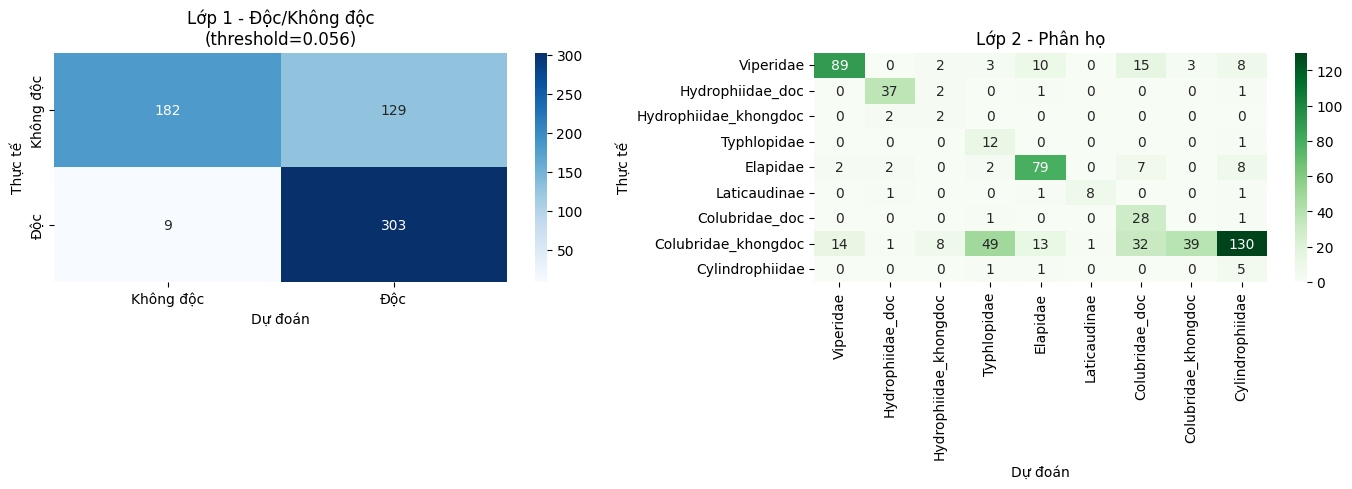


📊 Confusion matrix đã lưu lên Drive


In [ ]:
# ============================================
# BƯỚC 7: Đánh giá trên Test Set - Hướng 2
# ============================================
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

# Load best checkpoint
checkpoint = torch.load(DRIVE_SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"✅ Loaded checkpoint epoch {checkpoint['epoch']}")

# --- Collect predictions trên test set ---
all_doc_logits, all_doc_labels = [], []
all_ho_preds,   all_ho_labels  = [], []

with torch.no_grad():
    for imgs, lbl_doc, lbl_ho in test_loader:
        imgs = imgs.to(DEVICE)
        logit_doc, logit_ho = model(imgs)

        all_doc_logits.append(logit_doc.detach().cpu().float().numpy())
        all_doc_labels.append(lbl_doc.numpy())
        all_ho_preds.append(logit_ho.argmax(1).detach().cpu().numpy())
        all_ho_labels.append(lbl_ho.numpy())

all_doc_logits = np.concatenate(all_doc_logits)
all_doc_labels = np.concatenate(all_doc_labels).astype(int)
all_ho_preds   = np.concatenate(all_ho_preds)
all_ho_labels  = np.concatenate(all_ho_labels)

doc_probs  = 1 / (1 + np.exp(-all_doc_logits))
doc_preds  = (doc_probs >= 0.5).astype(int)

# --- Threshold tối ưu (maximize recall với precision >= 0.70) ---
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(
    all_doc_labels, doc_probs)

valid = precisions[:-1] >= 0.70
if valid.any():
    best_thresh = thresholds[valid][np.argmax(recalls[:-1][valid])]
else:
    best_thresh = 0.5

doc_preds_tuned = (doc_probs >= best_thresh).astype(int)

# --- In kết quả ---
print(f"\n{'='*55}")
print(f"  TEST SET - Hướng 2 (best checkpoint epoch {checkpoint['epoch']})")
print(f"{'='*55}")

print(f"\n[Lớp 1 - Độc/Không độc] threshold=0.5")
print(classification_report(all_doc_labels, doc_preds,
      target_names=['Không độc', 'Độc'], zero_division=0))

print(f"\n[Lớp 1 - Tuned threshold={best_thresh:.3f}]")
print(classification_report(all_doc_labels, doc_preds_tuned,
      target_names=['Không độc', 'Độc'], zero_division=0))

print(f"AUC-ROC: {roc_auc_score(all_doc_labels, doc_probs):.4f}")

print(f"\n[Lớp 2 - Phân họ]")
print(classification_report(all_ho_labels, all_ho_preds,
      target_names=ho_classes, zero_division=0))

# --- Confusion matrix lớp 1 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_doc = confusion_matrix(all_doc_labels, doc_preds_tuned)
sns.heatmap(cm_doc, annot=True, fmt='d', ax=axes[0],
            xticklabels=['Không độc', 'Độc'],
            yticklabels=['Không độc', 'Độc'],
            cmap='Blues')
axes[0].set_title(f'Lớp 1 - Độc/Không độc\n(threshold={best_thresh:.3f})')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

cm_ho = confusion_matrix(all_ho_labels, all_ho_preds)
sns.heatmap(cm_ho, annot=True, fmt='d', ax=axes[1],
            xticklabels=[h.split()[-1] for h in ho_classes],
            yticklabels=[h.split()[-1] for h in ho_classes],
            cmap='Greens')
axes[1].set_title('Lớp 2 - Phân họ')
axes[1].set_ylabel('Thực tế')
axes[1].set_xlabel('Dự đoán')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_huong2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Confusion matrix đã lưu lên Drive")

In [ ]:
# ============================================
# BƯỚC 8: Chuẩn bị dữ liệu cho Hướng 1
# Train 3 model riêng: A (binary), B (họ_doc), C (họ_khongdoc)
# ============================================

# --- Dataset cho Model A: toàn bộ ảnh, chỉ label doc ---
class SnakeDatasetDoc(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:    img = Image.open(row['path']).convert('RGB')
        except: img = Image.new('RGB', (224, 224), 0)
        if self.transform: img = self.transform(img)
        return img, int(row['label_doc'])

# --- Dataset cho Model B và C: chỉ label ho, re-index từ 0 ---
class SnakeDatasetHo(Dataset):
    def __init__(self, dataframe, label_col, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.label_col = label_col
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:    img = Image.open(row['path']).convert('RGB')
        except: img = Image.new('RGB', (224, 224), 0)
        if self.transform: img = self.transform(img)
        return img, int(row[self.label_col])

# --- Tách train/val/test theo doc_status ---
train_doc = train_df[train_df['doc_status'] == 'Co_doc'].copy()
train_kdoc= train_df[train_df['doc_status'] == 'Khong_doc'].copy()
val_doc   = val_df[val_df['doc_status']   == 'Co_doc'].copy()
val_kdoc  = val_df[val_df['doc_status']   == 'Khong_doc'].copy()

# Re-index label_ho trong từng nhóm (0, 1, 2, ...)
ho_doc_classes  = sorted(train_doc['label_ho_raw'].unique())
ho_kdoc_classes = sorted(train_kdoc['label_ho_raw'].unique())
ho_doc2idx      = {h: i for i, h in enumerate(ho_doc_classes)}
ho_kdoc2idx     = {h: i for i, h in enumerate(ho_kdoc_classes)}

for df_ in [train_doc, val_doc,
            test_df[test_df['doc_status']=='Co_doc'].copy()]:
    df_['label_ho_b'] = df_['label_ho_raw'].map(ho_doc2idx)

for df_ in [train_kdoc, val_kdoc,
            test_df[test_df['doc_status']=='Khong_doc'].copy()]:
    df_['label_ho_c'] = df_['label_ho_raw'].map(ho_kdoc2idx)

# Áp dụng mapping vào toàn bộ df để dùng sau
train_doc = train_doc.copy()
train_doc['label_ho_b'] = train_doc['label_ho_raw'].map(ho_doc2idx)
val_doc   = val_doc.copy()
val_doc['label_ho_b']   = val_doc['label_ho_raw'].map(ho_doc2idx)

train_kdoc = train_kdoc.copy()
train_kdoc['label_ho_c'] = train_kdoc['label_ho_raw'].map(ho_kdoc2idx)
val_kdoc   = val_kdoc.copy()
val_kdoc['label_ho_c']   = val_kdoc['label_ho_raw'].map(ho_kdoc2idx)

test_doc  = test_df[test_df['doc_status']=='Co_doc'].copy()
test_kdoc = test_df[test_df['doc_status']=='Khong_doc'].copy()
test_doc['label_ho_b']    = test_doc['label_ho_raw'].map(ho_doc2idx)
test_kdoc['label_ho_c']   = test_kdoc['label_ho_raw'].map(ho_kdoc2idx)

# --- Thống kê ---
print("=== Model A (toàn bộ) ===")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

print(f"\n=== Model B (chỉ Co_doc) — {len(ho_doc_classes)} họ ===")
for i, h in enumerate(ho_doc_classes):
    n = (train_doc['label_ho_b'] == i).sum()
    print(f"  [{i}] {h}: {n} train")

print(f"\n=== Model C (chỉ Khong_doc) — {len(ho_kdoc_classes)} họ ===")
for i, h in enumerate(ho_kdoc_classes):
    n = (train_kdoc['label_ho_c'] == i).sum()
    print(f"  [{i}] {h}: {n} train")

=== Model A (toàn bộ) ===
Train: 2907 | Val: 623 | Test: 623

=== Model B (chỉ Co_doc) — 5 họ ===
  [0] Họ rắn lục Viperidae: 609 train
  [1] Rắn biển Hydrophiidae_doc: 194 train
  [2] Rắn hổ Elapidae: 465 train
  [3] Rắn hổ biển Laticaudinae: 49 train
  [4] Rắn nước Colubridae_doc: 140 train

=== Model C (chỉ Khong_doc) — 4 họ ===
  [0] Rắn biển Hydrophiidae_khongdoc: 20 train
  [1] Rắn giun Typhlopidae: 57 train
  [2] Rắn nước Colubridae_khongdoc: 1338 train
  [3] Rắn trun Cylindrophiidae: 35 train


In [ ]:
# ============================================
# BƯỚC 9: Train Hướng 1 — Model A, B, C
# ============================================

DRIVE_A = '/content/drive/MyDrive/snake_modelA_best.pt'
DRIVE_B = '/content/drive/MyDrive/snake_modelB_best.pt'
DRIVE_C = '/content/drive/MyDrive/snake_modelC_best.pt'

def make_weighted_sampler(df, label_col):
    counts  = df[label_col].value_counts().sort_index().values
    weights = 1.0 / counts
    sample_w= df[label_col].map(lambda x: weights[x]).values
    return WeightedRandomSampler(
        torch.DoubleTensor(sample_w), len(df), replacement=True)

def make_loaders_doc(tr, va, te):
    """Model A: label = label_doc"""
    return (
        DataLoader(SnakeDatasetDoc(tr, train_transform),
                   batch_size=32, sampler=make_weighted_sampler(tr,'label_doc'),
                   num_workers=2, pin_memory=True),
        DataLoader(SnakeDatasetDoc(va, val_transform),
                   batch_size=32, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(SnakeDatasetDoc(te, val_transform),
                   batch_size=32, shuffle=False, num_workers=2, pin_memory=True),
    )

def make_loaders_ho(tr, va, te, label_col):
    """Model B/C: label = label_ho_b hoặc label_ho_c"""
    return (
        DataLoader(SnakeDatasetHo(tr, label_col, train_transform),
                   batch_size=32, sampler=make_weighted_sampler(tr, label_col),
                   num_workers=2, pin_memory=True),
        DataLoader(SnakeDatasetHo(va, label_col, val_transform),
                   batch_size=32, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(SnakeDatasetHo(te, label_col, val_transform),
                   batch_size=32, shuffle=False, num_workers=2, pin_memory=True),
    )

# --- Model đơn (1 head) ---
class SnakeViTSingle(nn.Module):
    def __init__(self, num_classes, binary=False):
        super().__init__()
        self.vit    = ViTModel.from_pretrained(
            'google/vit-base-patch16-224-in21k')
        hidden      = self.vit.config.hidden_size
        self.binary = binary
        out         = 1 if binary else num_classes
        self.head   = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden, out))

    def forward(self, x):
        cls = self.vit(x).last_hidden_state[:, 0]
        out = self.head(cls)
        return out.squeeze(1) if self.binary else out

def train_single(model, tr_loader, va_loader, criterion, save_path,
                 epochs=20, patience=4, binary=False, label=''):
    """Train loop cho 1 model đơn."""
    set_backbone_grad(False)   # phase 1: frozen
    opt = torch.optim.AdamW([
        {'params': model.head.parameters(), 'lr': 2e-4}
    ], weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=5, eta_min=1e-6)

    best_loss, patience_cnt = float('inf'), 0
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"{'Ep':>3} | {'Phase':>7} | {'TrLoss':>7} | {'ValLoss':>7} | "
          f"{'Acc':>6} | {'F1':>6} | {'Rec':>6} | {'s':>4}")
    print("-" * 65)

    for epoch in range(1, epochs + 1):
        if epoch == 6:   # unfreeze
            for p in model.vit.parameters(): p.requires_grad = True
            opt = torch.optim.AdamW([
                {'params': model.vit.parameters(),  'lr': 2e-5},
                {'params': model.head.parameters(), 'lr': 2e-4},
            ], weight_decay=1e-4)
            sch = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=epochs-5, eta_min=1e-7)

        phase = 'FROZEN' if epoch <= 5 else 'FULL'
        model.train()
        t0, tr_loss = time.time(), 0
        for imgs, lbls in tr_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            lbls = lbls.float() if binary else lbls.long()
            out  = model(imgs)
            loss = criterion(out, lbls)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item()
        sch.step()

        model.eval()
        va_loss = 0
        all_logits, all_labels = [], []
        with torch.no_grad():
            for imgs, lbls in va_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                lbls_f = lbls.float() if binary else lbls.long()
                out    = model(imgs)
                va_loss += criterion(out, lbls_f).item()
                all_logits.append(out.cpu().float().numpy())
                all_labels.append(lbls.cpu().numpy())

        all_logits = np.concatenate(all_logits)
        all_labels = np.concatenate(all_labels)

        if binary:
            preds = (1/(1+np.exp(-all_logits)) >= 0.5).astype(int)
            rec   = recall_score(all_labels, preds, pos_label=1, zero_division=0)
        else:
            preds = all_logits.argmax(1)
            rec   = 0.0

        acc = accuracy_score(all_labels, preds)
        f1  = f1_score(all_labels, preds, average='weighted', zero_division=0)
        vl  = va_loss / len(va_loader)
        tl  = tr_loss / len(tr_loader)
        elapsed = time.time() - t0

        saved = ''
        if vl < best_loss:
            best_loss, patience_cnt = vl, 0
            torch.save({'model_state': model.state_dict(),
                        'epoch': epoch}, save_path)
            saved = '💾'
        else:
            patience_cnt += 1
            if phase == 'FULL' and patience_cnt >= patience:
                print(f"  ⏹ Early stop epoch {epoch}")
                break

        print(f"{epoch:>3} | {phase:>7} | {tl:>7.4f} | {vl:>7.4f} | "
              f"{acc:>6.4f} | {f1:>6.4f} | {rec:>6.4f} | {elapsed:>3.0f}s {saved}")

    print(f"  Best val loss: {best_loss:.4f} → {save_path}")
    return best_loss

# ── Model A ──────────────────────────────────────────────
loaderA_tr, loaderA_va, loaderA_te = make_loaders_doc(
    train_df, val_df, test_df)
modelA = SnakeViTSingle(num_classes=2, binary=True).to(DEVICE)
pos_w  = torch.tensor([
    (train_df['label_doc']==0).sum()/(train_df['label_doc']==1).sum()
], dtype=torch.float32).to(DEVICE)
critA  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
train_single(modelA, loaderA_tr, loaderA_va, critA, DRIVE_A,
             binary=True, label='MODEL A — Độc/Không độc (toàn bộ ảnh)')

# ── Model B ──────────────────────────────────────────────
loaderB_tr, loaderB_va, loaderB_te = make_loaders_ho(
    train_doc, val_doc, test_doc, 'label_ho_b')
modelB = SnakeViTSingle(num_classes=len(ho_doc_classes)).to(DEVICE)
b_counts = train_doc['label_ho_b'].value_counts().sort_index().values
b_w = torch.tensor(1.0/b_counts, dtype=torch.float32).to(DEVICE)
b_w = b_w / b_w.sum() * len(ho_doc_classes)
critB = nn.CrossEntropyLoss(weight=b_w)
train_single(modelB, loaderB_tr, loaderB_va, critB, DRIVE_B,
             label='MODEL B — Phân họ (chỉ Co_doc, 5 họ)')

# ── Model C ──────────────────────────────────────────────
loaderC_tr, loaderC_va, loaderC_te = make_loaders_ho(
    train_kdoc, val_kdoc, test_kdoc, 'label_ho_c')
modelC = SnakeViTSingle(num_classes=len(ho_kdoc_classes)).to(DEVICE)
c_counts = train_kdoc['label_ho_c'].value_counts().sort_index().values
c_w = torch.tensor(1.0/c_counts, dtype=torch.float32).to(DEVICE)
c_w = c_w / c_w.sum() * len(ho_kdoc_classes)
critC = nn.CrossEntropyLoss(weight=c_w)
train_single(modelC, loaderC_tr, loaderC_va, critC, DRIVE_C,
             label='MODEL C — Phân họ (chỉ Khong_doc, 4 họ)')

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


  MODEL A — Độc/Không độc (toàn bộ ảnh)
 Ep |   Phase |  TrLoss | ValLoss |    Acc |     F1 |    Rec |    s
-----------------------------------------------------------------
  1 |  FROZEN |  0.6811 |  0.6641 | 0.6758 | 0.6748 | 0.7284 | 100s 💾
  2 |  FROZEN |  0.6611 |  0.6419 | 0.7127 | 0.7125 | 0.6901 | 102s 💾
  3 |  FROZEN |  0.6440 |  0.6293 | 0.7079 | 0.7076 | 0.6741 | 102s 💾
  4 |  FROZEN |  0.6404 |  0.6234 | 0.7191 | 0.7191 | 0.7061 | 102s 💾
  5 |  FROZEN |  0.6341 |  0.6217 | 0.7191 | 0.7191 | 0.7061 | 102s 💾
  6 |    FULL |  0.5458 |  0.4970 | 0.7801 | 0.7762 | 0.9105 | 103s 💾
  7 |    FULL |  0.3778 |  0.3847 | 0.8347 | 0.8346 | 0.8083 | 105s 💾
  8 |    FULL |  0.2631 |  0.3537 | 0.8475 | 0.8471 | 0.8946 | 104s 💾
  9 |    FULL |  0.1878 |  0.3547 | 0.8571 | 0.8570 | 0.8243 | 104s 
 10 |    FULL |  0.1230 |  0.3978 | 0.8571 | 0.8570 | 0.8914 | 104s 
 11 |    FULL |  0.0840 |  0.3912 | 0.8748 | 0.8745 | 0.9233 | 103s 
  ⏹ Early stop epoch 12
  Best val loss: 0.3537 → /content

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


  MODEL B — Phân họ (chỉ Co_doc, 5 họ)
 Ep |   Phase |  TrLoss | ValLoss |    Acc |     F1 |    Rec |    s
-----------------------------------------------------------------
  1 |  FROZEN |  1.3988 |  1.5889 | 0.0735 | 0.0413 | 0.0000 |  53s 💾
  2 |  FROZEN |  1.1620 |  1.5799 | 0.0958 | 0.0436 | 0.0000 |  52s 💾
  3 |  FROZEN |  1.0475 |  1.5654 | 0.1022 | 0.0369 | 0.0000 |  52s 💾
  4 |  FROZEN |  0.9584 |  1.5657 | 0.1182 | 0.0414 | 0.0000 |  51s 
  5 |  FROZEN |  0.9348 |  1.5643 | 0.1182 | 0.0410 | 0.0000 |  52s 💾
  6 |    FULL |  0.6834 |  1.1721 | 0.2141 | 0.1330 | 0.0000 |  54s 💾
  7 |    FULL |  0.3810 |  0.7207 | 0.6773 | 0.7053 | 0.0000 |  54s 💾
  8 |    FULL |  0.1823 |  0.4823 | 0.8179 | 0.8219 | 0.0000 |  53s 💾
  9 |    FULL |  0.0974 |  0.3609 | 0.8722 | 0.8725 | 0.0000 |  54s 💾
 10 |    FULL |  0.0616 |  0.3076 | 0.8946 | 0.8973 | 0.0000 |  52s 💾
 11 |    FULL |  0.0386 |  0.2980 | 0.9010 | 0.9015 | 0.0000 |  52s 💾
 12 |    FULL |  0.0288 |  0.2874 | 0.9201 | 0.9201 | 0.0

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


  MODEL C — Phân họ (chỉ Khong_doc, 4 họ)
 Ep |   Phase |  TrLoss | ValLoss |    Acc |     F1 |    Rec |    s
-----------------------------------------------------------------
  1 |  FROZEN |  1.2372 |  1.3508 | 0.0452 | 0.0268 | 0.0000 |  52s 💾
  2 |  FROZEN |  1.0250 |  1.3190 | 0.0581 | 0.0290 | 0.0000 |  53s 💾
  3 |  FROZEN |  0.8918 |  1.3083 | 0.0613 | 0.0286 | 0.0000 |  51s 💾
  4 |  FROZEN |  0.8383 |  1.3070 | 0.0613 | 0.0277 | 0.0000 |  53s 💾
  5 |  FROZEN |  0.8009 |  1.3070 | 0.0613 | 0.0264 | 0.0000 |  52s 
  6 |    FULL |  0.4365 |  1.1851 | 0.0742 | 0.0217 | 0.0000 |  52s 💾
  7 |    FULL |  0.1123 |  1.1789 | 0.0742 | 0.0188 | 0.0000 |  53s 💾
  8 |    FULL |  0.0509 |  1.0223 | 0.0742 | 0.0204 | 0.0000 |  54s 💾
  9 |    FULL |  0.0380 |  0.7912 | 0.0871 | 0.0406 | 0.0000 |  53s 💾
 10 |    FULL |  0.0286 |  0.5954 | 0.3871 | 0.4919 | 0.0000 |  52s 💾
 11 |    FULL |  0.0210 |  0.4770 | 0.6613 | 0.7513 | 0.0000 |  54s 💾
 12 |    FULL |  0.0142 |  0.4095 | 0.8323 | 0.8750 | 

0.38437763750553133

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Loaded Model A, B, C

  TEST SET — Hướng 1

[Lớp 1 - Model A] threshold=0.5
              precision    recall  f1-score   support

   Không độc       0.86      0.82      0.84       311
         Độc       0.83      0.87      0.85       312

    accuracy                           0.84       623
   macro avg       0.84      0.84      0.84       623
weighted avg       0.84      0.84      0.84       623

AUC-ROC: 0.9124

[Lớp 2 - Chốt cứng]
                                precision    recall  f1-score   support

          Họ rắn lục Viperidae       0.83      0.83      0.83       130
     Rắn biển Hydrophiidae_doc       0.83      0.85      0.84        41
Rắn biển Hydrophiidae_khongdoc       0.20      0.25      0.22         4
          Rắn giun Typhlopidae       0.50      0.92      0.65        13
               Rắn hổ Elapidae       0.71      0.82      0.76       100
      Rắn hổ biển Laticaudinae       1.00      0.73      0.84        11
       Rắn nước Colubridae_doc       0.72      0.77  

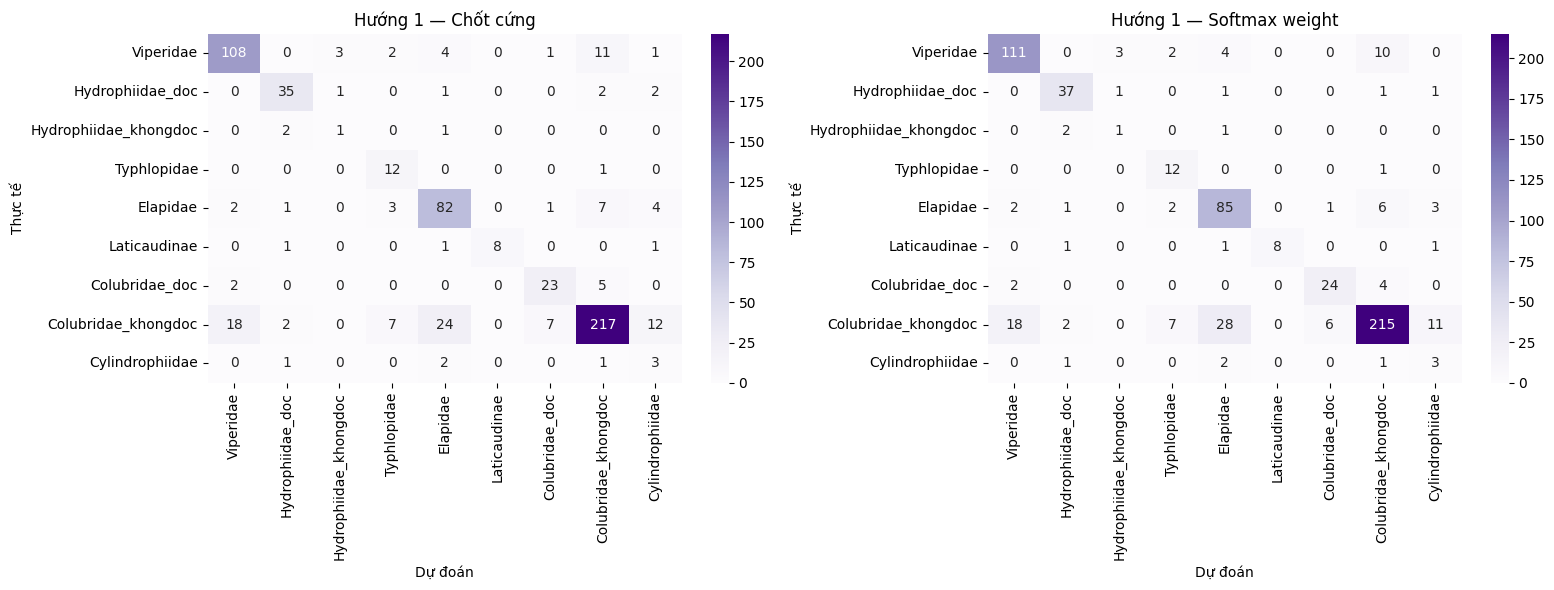


📊 Đã lưu confusion matrix Hướng 1 lên Drive


In [ ]:
# ============================================
# BƯỚC 10: Đánh giá Hướng 1 trên Test Set
# So sánh: chốt cứng vs softmax weight
# ============================================
from sklearn.metrics import classification_report, roc_auc_score

# --- Load 3 model ---
modelA = SnakeViTSingle(num_classes=2, binary=True).to(DEVICE)
modelA.load_state_dict(torch.load(DRIVE_A, map_location=DEVICE)['model_state'])
modelA.eval()

modelB = SnakeViTSingle(num_classes=len(ho_doc_classes)).to(DEVICE)
modelB.load_state_dict(torch.load(DRIVE_B, map_location=DEVICE)['model_state'])
modelB.eval()

modelC = SnakeViTSingle(num_classes=len(ho_kdoc_classes)).to(DEVICE)
modelC.load_state_dict(torch.load(DRIVE_C, map_location=DEVICE)['model_state'])
modelC.eval()

print("✅ Loaded Model A, B, C")

# --- Inference trên toàn bộ test set ---
# Cần chạy cả 3 model trên từng ảnh test
class SnakeTestDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:    img = Image.open(row['path']).convert('RGB')
        except: img = Image.new('RGB', (224, 224), 0)
        if self.transform: img = self.transform(img)
        return img, int(row['label_doc']), int(row['label_ho'])

test_loader_full = DataLoader(
    SnakeTestDataset(test_df, val_transform),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

all_logit_a, all_logit_b, all_logit_c = [], [], []
all_label_doc, all_label_ho = [], []

with torch.no_grad():
    for imgs, lbl_doc, lbl_ho in test_loader_full:
        imgs = imgs.to(DEVICE)
        out_a = modelA(imgs).cpu().float().numpy()
        out_b = modelB(imgs).cpu().float().numpy()
        out_c = modelC(imgs).cpu().float().numpy()

        all_logit_a.append(out_a)
        all_logit_b.append(out_b)
        all_logit_c.append(out_c)
        all_label_doc.append(lbl_doc.numpy())
        all_label_ho.append(lbl_ho.numpy())

all_logit_a   = np.concatenate(all_logit_a)
all_logit_b   = np.concatenate(all_logit_b)
all_logit_c   = np.concatenate(all_logit_c)
all_label_doc = np.concatenate(all_label_doc).astype(int)
all_label_ho  = np.concatenate(all_label_ho).astype(int)

# Xác suất độc từ Model A
prob_doc = 1 / (1 + np.exp(-all_logit_a))  # shape (N,)

# Softmax cho B và C
def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

prob_b = softmax(all_logit_b)  # (N, 5)
prob_c = softmax(all_logit_c)  # (N, 4)

# ── Cách 1: Chốt cứng ────────────────────────────────────
doc_pred_hard = (prob_doc >= 0.5).astype(int)

# Map B prediction → label_ho gốc (0-8)
b2ho = {i: ho2idx[h] for i, h in enumerate(ho_doc_classes)}
c2ho = {i: ho2idx[h] for i, h in enumerate(ho_kdoc_classes)}

ho_pred_hard = np.where(
    doc_pred_hard == 1,
    np.array([b2ho[i] for i in prob_b.argmax(1)]),
    np.array([c2ho[i] for i in prob_c.argmax(1)])
)

# ── Cách 2: Softmax weight ───────────────────────────────
# Tạo full prob vector (9 classes) bằng cách weight B và C
N = len(all_label_doc)
prob_ho_full = np.zeros((N, len(ho_classes)))

for i_b, i_ho in b2ho.items():
    prob_ho_full[:, i_ho] += prob_doc * prob_b[:, i_b]

for i_c, i_ho in c2ho.items():
    prob_ho_full[:, i_ho] += (1 - prob_doc) * prob_c[:, i_c]

ho_pred_soft = prob_ho_full.argmax(1)

# ── In kết quả ───────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  TEST SET — Hướng 1")
print(f"{'='*60}")

print(f"\n[Lớp 1 - Model A] threshold=0.5")
print(classification_report(all_label_doc, doc_pred_hard,
      target_names=['Không độc', 'Độc'], zero_division=0))
print(f"AUC-ROC: {roc_auc_score(all_label_doc, prob_doc):.4f}")

print(f"\n[Lớp 2 - Chốt cứng]")
print(classification_report(all_label_ho, ho_pred_hard,
      target_names=ho_classes, zero_division=0))

print(f"\n[Lớp 2 - Softmax weight]")
print(classification_report(all_label_ho, ho_pred_soft,
      target_names=ho_classes, zero_division=0))

# ── Confusion matrix ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
short = [h.split()[-1] for h in ho_classes]

for ax, preds, title in zip(
    axes,
    [ho_pred_hard, ho_pred_soft],
    ['Hướng 1 — Chốt cứng', 'Hướng 1 — Softmax weight']
):
    cm = confusion_matrix(all_label_ho, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=short, yticklabels=short, cmap='Purples')
    ax.set_title(title)
    ax.set_ylabel('Thực tế')
    ax.set_xlabel('Dự đoán')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_huong1.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Đã lưu confusion matrix Hướng 1 lên Drive")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Loaded: H2 (Lớp 1) + Model B + Model C
📌 Threshold tối ưu (recall ưu tiên, precision≥0.70): 0.0510

  TEST SET — Hybrid Pipeline
  (Lớp 1: H2 threshold=0.051 | Lớp 2: H1 chốt cứng)

[Lớp 1 - Độc/Không độc]
              precision    recall  f1-score   support

   Không độc       0.95      0.58      0.72       311
         Độc       0.70      0.97      0.81       312

    accuracy                           0.77       623
   macro avg       0.82      0.77      0.76       623
weighted avg       0.82      0.77      0.76       623

AUC-ROC: 0.9207

[Lớp 2 - Phân họ]
                                precision    recall  f1-score   support

          Họ rắn lục Viperidae       0.66      0.93      0.77       130
     Rắn biển Hydrophiidae_doc       0.78      0.98      0.87        41
Rắn biển Hydrophiidae_khongdoc       1.00      0.50      0.67         4
          Rắn giun Typhlopidae       0.60      0.92      0.73        13
               Rắn hổ Elapidae       0.64      0.92      0.75       1

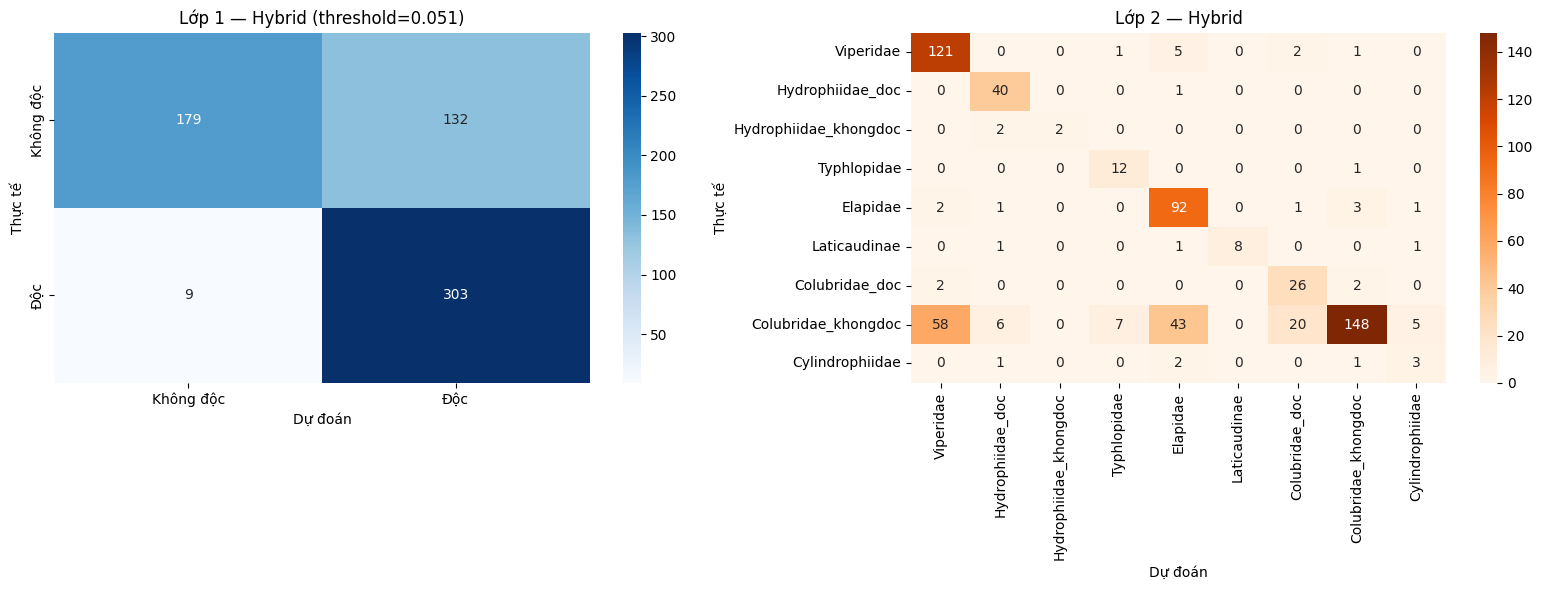


📊 Đã lưu confusion matrix Hybrid lên Drive


In [ ]:
# ============================================
# BƯỚC 11: Pipeline Hybrid
# Lớp 1: Model Hướng 2 (joint ViT)
# Lớp 2: Model B hoặc C tùy kết quả Lớp 1
# ============================================

# Load model Hướng 2 (đã có từ trước)
model_h2 = SnakeViT(NUM_HO).to(DEVICE)
ckpt_h2  = torch.load(DRIVE_SAVE_PATH, map_location=DEVICE)
model_h2.load_state_dict(ckpt_h2['model_state'])
model_h2.eval()

# Load Model B và C (đã có từ trước)
modelB = SnakeViTSingle(num_classes=len(ho_doc_classes)).to(DEVICE)
modelB.load_state_dict(torch.load(DRIVE_B, map_location=DEVICE)['model_state'])
modelB.eval()

modelC = SnakeViTSingle(num_classes=len(ho_kdoc_classes)).to(DEVICE)
modelC.load_state_dict(torch.load(DRIVE_C, map_location=DEVICE)['model_state'])
modelC.eval()

print("✅ Loaded: H2 (Lớp 1) + Model B + Model C")

# Threshold tuned từ Hướng 2 (ưu tiên recall độc)
# Tìm lại trên val set
all_val_logits, all_val_labels = [], []
with torch.no_grad():
    for imgs, lbl_doc, lbl_ho in val_loader:
        imgs = imgs.to(DEVICE)
        logit_doc, _ = model_h2(imgs)
        all_val_logits.append(logit_doc.cpu().float().numpy())
        all_val_labels.append(lbl_doc.numpy())

val_logits = np.concatenate(all_val_logits)
val_labels = np.concatenate(all_val_labels).astype(int)
val_probs  = 1 / (1 + np.exp(-val_logits))

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
valid = precisions[:-1] >= 0.70
THRESHOLD = float(thresholds[valid][np.argmax(recalls[:-1][valid])]) if valid.any() else 0.5
print(f"📌 Threshold tối ưu (recall ưu tiên, precision≥0.70): {THRESHOLD:.4f}")

# ── Inference hybrid trên test set ───────────────────────
def hybrid_inference(loader):
    all_prob_doc  = []
    all_pred_doc  = []
    all_pred_ho   = []
    all_label_doc = []
    all_label_ho  = []

    with torch.no_grad():
        for imgs, lbl_doc, lbl_ho in loader:
            imgs = imgs.to(DEVICE)

            # Lớp 1: Hướng 2
            logit_doc, _ = model_h2(imgs)
            prob_doc = torch.sigmoid(logit_doc).cpu().float().numpy()
            pred_doc = (prob_doc >= THRESHOLD).astype(int)

            # Lớp 2: B hoặc C theo pred_doc
            out_b = modelB(imgs).cpu().float().numpy()
            out_c = modelC(imgs).cpu().float().numpy()

            def softmax(x):
                e = np.exp(x - x.max(axis=1, keepdims=True))
                return e / e.sum(axis=1, keepdims=True)

            # Chốt cứng
            pred_ho = np.where(
                pred_doc == 1,
                np.array([b2ho[i] for i in out_b.argmax(1)]),
                np.array([c2ho[i] for i in out_c.argmax(1)])
            )

            all_prob_doc.append(prob_doc)
            all_pred_doc.append(pred_doc)
            all_pred_ho.append(pred_ho)
            all_label_doc.append(lbl_doc.numpy())
            all_label_ho.append(lbl_ho.numpy())

    return {
        'prob_doc' : np.concatenate(all_prob_doc),
        'pred_doc' : np.concatenate(all_pred_doc),
        'pred_ho'  : np.concatenate(all_pred_ho),
        'label_doc': np.concatenate(all_label_doc).astype(int),
        'label_ho' : np.concatenate(all_label_ho).astype(int),
    }

results = hybrid_inference(test_loader)

# ── In kết quả ───────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  TEST SET — Hybrid Pipeline")
print(f"  (Lớp 1: H2 threshold={THRESHOLD:.3f} | Lớp 2: H1 chốt cứng)")
print(f"{'='*60}")

print(f"\n[Lớp 1 - Độc/Không độc]")
print(classification_report(results['label_doc'], results['pred_doc'],
      target_names=['Không độc', 'Độc'], zero_division=0))
print(f"AUC-ROC: {roc_auc_score(results['label_doc'], results['prob_doc']):.4f}")

print(f"\n[Lớp 2 - Phân họ]")
print(classification_report(results['label_ho'], results['pred_ho'],
      target_names=ho_classes, zero_division=0))

# ── Confusion matrix ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
short = [h.split()[-1] for h in ho_classes]

cm1 = confusion_matrix(results['label_doc'], results['pred_doc'])
sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0],
            xticklabels=['Không độc', 'Độc'],
            yticklabels=['Không độc', 'Độc'], cmap='Blues')
axes[0].set_title(f'Lớp 1 — Hybrid (threshold={THRESHOLD:.3f})')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

cm2 = confusion_matrix(results['label_ho'], results['pred_ho'])
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[1],
            xticklabels=short, yticklabels=short, cmap='Oranges')
axes[1].set_title('Lớp 2 — Hybrid')
axes[1].set_ylabel('Thực tế'); axes[1].set_xlabel('Dự đoán')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_hybrid.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Đã lưu confusion matrix Hybrid lên Drive")

In [ ]:
# ============================================
# BƯỚC 11b: Hybrid với threshold=0.5
# ============================================

def hybrid_inference_with_threshold(loader, threshold):
    all_prob_doc  = []
    all_pred_doc  = []
    all_pred_ho   = []
    all_label_doc = []
    all_label_ho  = []

    with torch.no_grad():
        for imgs, lbl_doc, lbl_ho in loader:
            imgs = imgs.to(DEVICE)

            logit_doc, _ = model_h2(imgs)
            prob_doc = torch.sigmoid(logit_doc).cpu().float().numpy()
            pred_doc = (prob_doc >= threshold).astype(int)

            out_b = modelB(imgs).cpu().float().numpy()
            out_c = modelC(imgs).cpu().float().numpy()

            pred_ho = np.where(
                pred_doc == 1,
                np.array([b2ho[i] for i in out_b.argmax(1)]),
                np.array([c2ho[i] for i in out_c.argmax(1)])
            )

            all_prob_doc.append(prob_doc)
            all_pred_doc.append(pred_doc)
            all_pred_ho.append(pred_ho)
            all_label_doc.append(lbl_doc.numpy())
            all_label_ho.append(lbl_ho.numpy())

    return {
        'prob_doc' : np.concatenate(all_prob_doc),
        'pred_doc' : np.concatenate(all_pred_doc),
        'pred_ho'  : np.concatenate(all_pred_ho),
        'label_doc': np.concatenate(all_label_doc).astype(int),
        'label_ho' : np.concatenate(all_label_ho).astype(int),
    }

results_05 = hybrid_inference_with_threshold(test_loader, 0.5)

print(f"\n{'='*60}")
print(f"  TEST SET — Hybrid (threshold=0.5)")
print(f"{'='*60}")

print(f"\n[Lớp 1]")
print(classification_report(results_05['label_doc'], results_05['pred_doc'],
      target_names=['Không độc', 'Độc'], zero_division=0))
print(f"AUC-ROC: {roc_auc_score(results_05['label_doc'], results_05['prob_doc']):.4f}")

print(f"\n[Lớp 2]")
print(classification_report(results_05['label_ho'], results_05['pred_ho'],
      target_names=ho_classes, zero_division=0))


  TEST SET — Hybrid (threshold=0.5)

[Lớp 1]
              precision    recall  f1-score   support

   Không độc       0.87      0.85      0.86       311
         Độc       0.85      0.87      0.86       312

    accuracy                           0.86       623
   macro avg       0.86      0.86      0.86       623
weighted avg       0.86      0.86      0.86       623

AUC-ROC: 0.9207

[Lớp 2]
                                precision    recall  f1-score   support

          Họ rắn lục Viperidae       0.80      0.82      0.81       130
     Rắn biển Hydrophiidae_doc       0.88      0.88      0.88        41
Rắn biển Hydrophiidae_khongdoc       0.33      0.50      0.40         4
          Rắn giun Typhlopidae       0.52      0.92      0.67        13
               Rắn hổ Elapidae       0.80      0.82      0.81       100
      Rắn hổ biển Laticaudinae       1.00      0.73      0.84        11
       Rắn nước Colubridae_doc       0.73      0.80      0.76        30
  Rắn nước Colubridae_kho

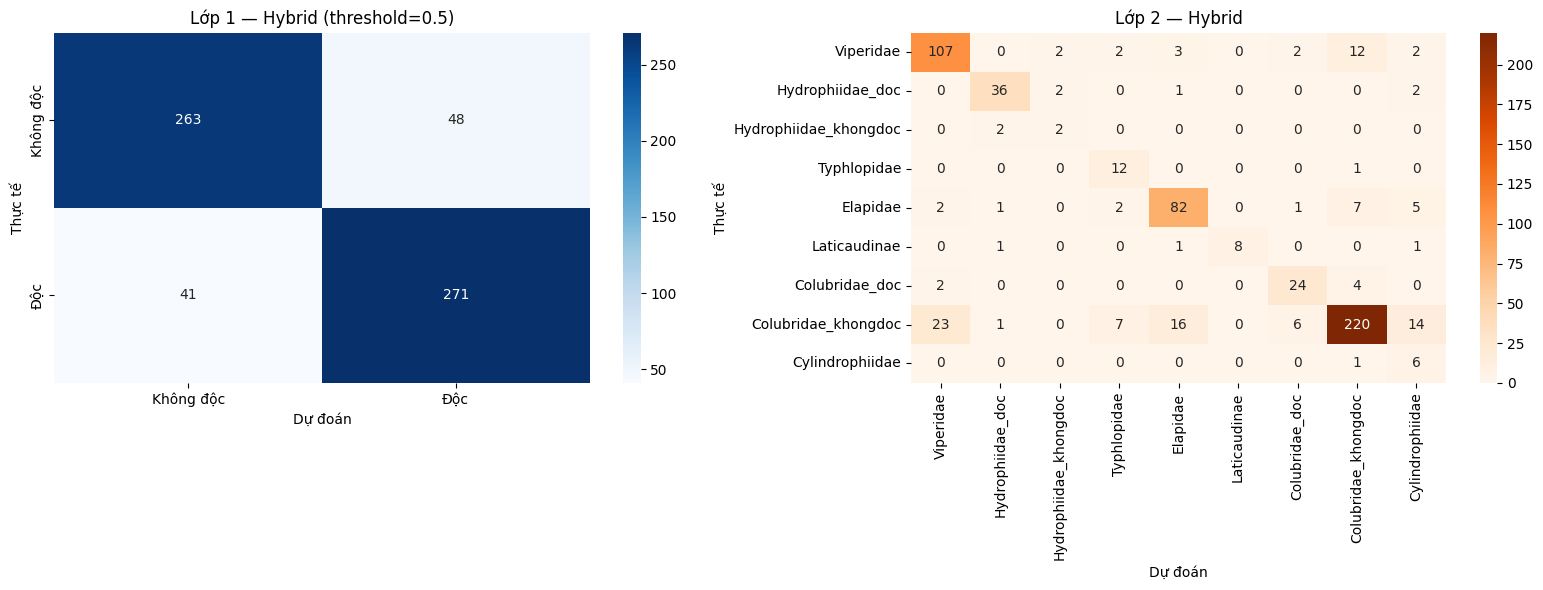

📊 Đã lưu lên Drive


In [ ]:
# ============================================
# Confusion matrix — Hybrid (threshold=0.5)
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
short = [h.split()[-1] for h in ho_classes]

cm1 = confusion_matrix(results_05['label_doc'], results_05['pred_doc'])
sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0],
            xticklabels=['Không độc', 'Độc'],
            yticklabels=['Không độc', 'Độc'], cmap='Blues')
axes[0].set_title('Lớp 1 — Hybrid (threshold=0.5)')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

cm2 = confusion_matrix(results_05['label_ho'], results_05['pred_ho'])
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[1],
            xticklabels=short, yticklabels=short, cmap='Oranges')
axes[1].set_title('Lớp 2 — Hybrid')
axes[1].set_ylabel('Thực tế')
axes[1].set_xlabel('Dự đoán')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_hybrid_05.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("📊 Đã lưu lên Drive")

In [ ]:
# ============================================
# BƯỚC 12 (fix 2): Đổi attention sang eager + reload model
# ============================================
from transformers import ViTModel, ViTConfig

def build_vit_eager():
    """Load ViT với attn_implementation='eager' để hỗ trợ output_attentions."""
    config = ViTConfig.from_pretrained('google/vit-base-patch16-224-in21k')
    config._attn_implementation = 'eager'
    vit = ViTModel.from_pretrained(
        'google/vit-base-patch16-224-in21k',
        config=config,
        attn_implementation='eager'
    )
    return vit

# Reload model_h2 với eager attention
class SnakeViTEager(nn.Module):
    def __init__(self, num_ho=9):
        super().__init__()
        self.vit      = build_vit_eager()
        hidden        = self.vit.config.hidden_size
        self.head_doc = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden, 1))
        self.head_ho  = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden, num_ho))

    def forward(self, x, output_attentions=False):
        out = self.vit(x, output_attentions=output_attentions)
        cls = out.last_hidden_state[:, 0]
        return self.head_doc(cls).squeeze(1), self.head_ho(cls), out.attentions

model_h2_eager = SnakeViTEager(NUM_HO).to(DEVICE)
ckpt = torch.load(DRIVE_SAVE_PATH, map_location=DEVICE)
# Load chỉ các key khớp (head_doc, head_ho giống nhau)
model_h2_eager.load_state_dict(ckpt['model_state'], strict=False)
model_h2_eager.eval()
print("✅ Loaded model_h2 với eager attention")

# Test output_attentions
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    _, _, attns = model_h2_eager(dummy, output_attentions=True)
print(f"✅ Attention layers: {len(attns)}, shape: {attns[0].shape}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Loaded model_h2 với eager attention
✅ Attention layers: 12, shape: torch.Size([1, 12, 197, 197])


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Sau đó chạy lại toàn bộ cell bước 12

🔍 Test visualization trên 3 ảnh mẫu...

Ảnh    : obs135929994_photo231915707_2.jpg
Thực tế: Không độc | Rắn nước Colubridae_khongdoc


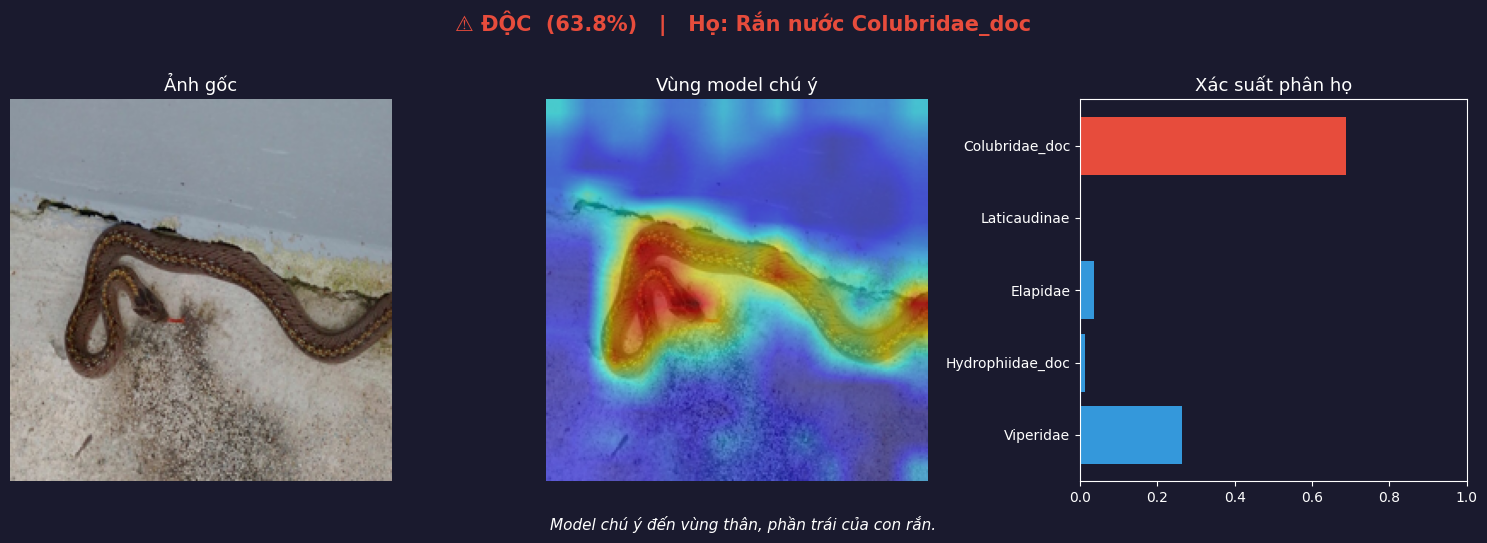

Dự đoán: ⚠️ Độc (63.8%) | Rắn nước Colubridae_doc
Giải thích: Model chú ý đến vùng thân, phần trái của con rắn.

Ảnh    : obs347334316_photo633280991_1.jpg
Thực tế: Không độc | Rắn nước Colubridae_khongdoc


/tmp/ipykernel_532/4050940047.py:113: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_532/4050940047.py:115: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


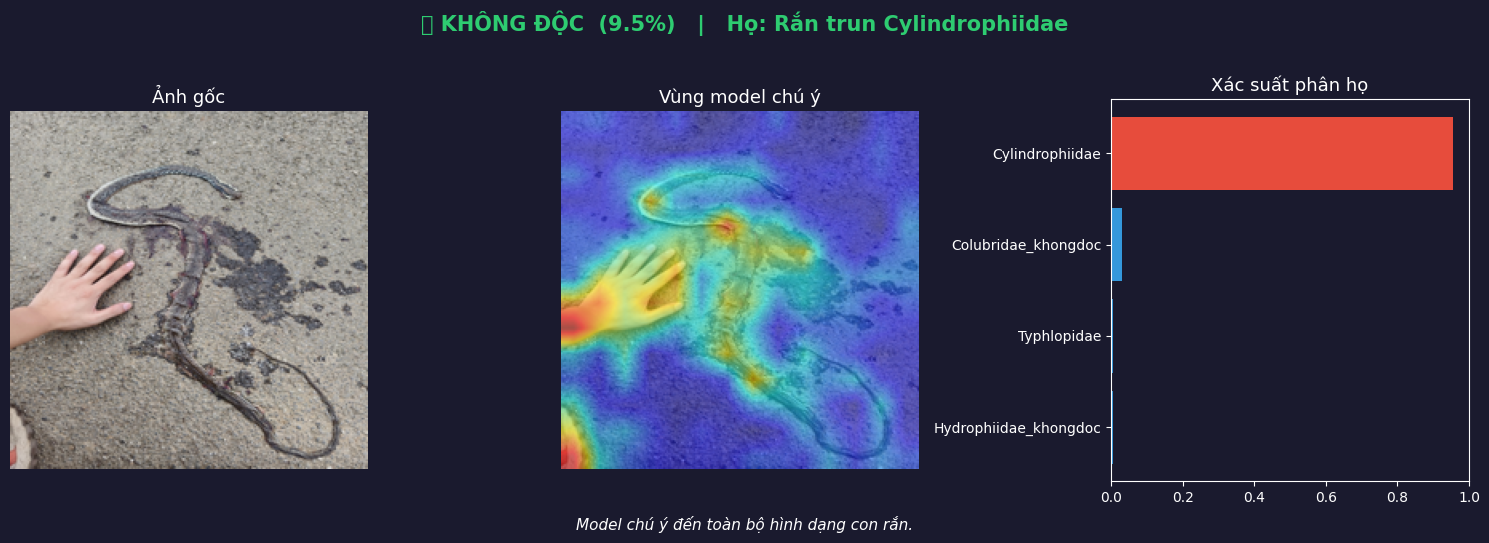

Dự đoán: ✅ Không độc (9.5%) | Rắn trun Cylindrophiidae
Giải thích: Model chú ý đến toàn bộ hình dạng con rắn.

Ảnh    : obs167012480_photo289267106_2.jpeg
Thực tế: Độc | Họ rắn lục Viperidae


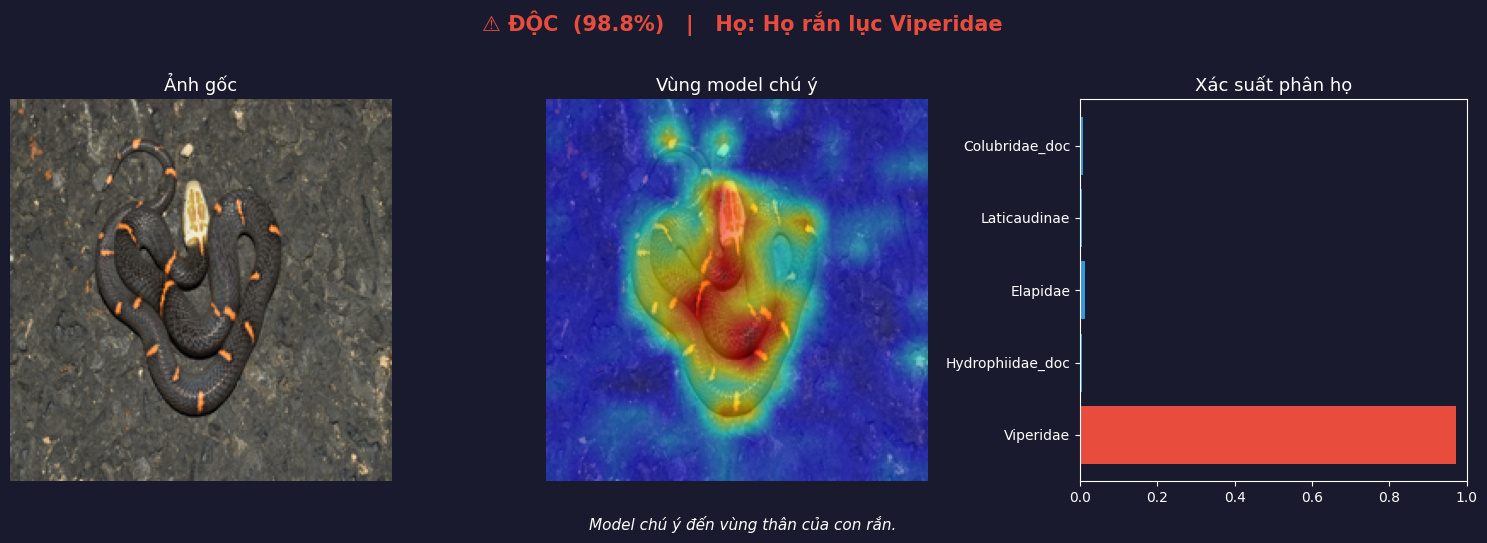

Dự đoán: ⚠️ Độc (98.8%) | Họ rắn lục Viperidae
Giải thích: Model chú ý đến vùng thân của con rắn.



In [ ]:
# ============================================
# BƯỚC 12 (final): Visualization với eager model
# ============================================

def get_attention_rollout(model_vit_eager, img_tensor):
    model_vit_eager.eval()
    with torch.no_grad():
        _, _, attentions = model_vit_eager(
            img_tensor.to(DEVICE), output_attentions=True)

    rollout = torch.eye(attentions[0].shape[-1])
    for attn in attentions:
        attn_avg = attn.squeeze(0).mean(0).cpu()  # (197, 197)
        attn_aug = attn_avg + torch.eye(attn_avg.shape[0])
        attn_aug = attn_aug / attn_aug.sum(dim=-1, keepdim=True)
        rollout  = torch.matmul(attn_aug, rollout)

    mask = rollout[0, 1:].numpy()       # (196,) bỏ CLS
    mask = mask.reshape(14, 14)
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    mask = cv2.resize(mask, (224, 224))
    return mask

def explain_attention(heatmap, threshold=0.6):
    h, w  = heatmap.shape
    hot   = heatmap >= threshold
    top   = hot[:h//3, :].mean()
    mid   = hot[h//3:2*h//3, :].mean()
    bot   = hot[2*h//3:, :].mean()
    left  = hot[:, :w//2].mean()
    right = hot[:, w//2:].mean()

    regions = []
    if top  > 0.15: regions.append("vùng đầu")
    if mid  > 0.15: regions.append("vùng thân")
    if bot  > 0.15: regions.append("vùng đuôi")
    if abs(left - right) > 0.1:
        regions.append("phần " + ("trái" if left > right else "phải"))
    if not regions:
        return "Model chú ý đến toàn bộ hình dạng con rắn."
    return f"Model chú ý đến {', '.join(regions)} của con rắn."

def predict_and_visualize(image_path, save_path=None):
    img_pil    = Image.open(image_path).convert('RGB')
    img_tensor = val_transform(img_pil).unsqueeze(0)

    # Lớp 1 — dùng model_h2_eager
    with torch.no_grad():
        logit_doc, _, _ = model_h2_eager(img_tensor.to(DEVICE))
    prob_doc = torch.sigmoid(logit_doc).item()
    pred_doc = int(prob_doc >= 0.5)

    # Lớp 2
    if pred_doc == 1:
        modelB.eval()
        with torch.no_grad():
            out_ho = modelB(img_tensor.to(DEVICE))
        probs_ho = torch.softmax(out_ho, dim=1).cpu().numpy()[0]
        ho_label = ho_doc_classes[probs_ho.argmax()]
        ho_probs_display = {ho_doc_classes[i]: float(probs_ho[i])
                            for i in range(len(ho_doc_classes))}
    else:
        modelC.eval()
        with torch.no_grad():
            out_ho = modelC(img_tensor.to(DEVICE))
        probs_ho = torch.softmax(out_ho, dim=1).cpu().numpy()[0]
        ho_label = ho_kdoc_classes[probs_ho.argmax()]
        ho_probs_display = {ho_kdoc_classes[i]: float(probs_ho[i])
                            for i in range(len(ho_kdoc_classes))}

    # Attention Rollout
    heatmap = get_attention_rollout(model_h2_eager, img_tensor)
    explain = explain_attention(heatmap)

    # Dashboard
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.patch.set_facecolor('#1a1a2e')
    img_np = np.array(img_pil.resize((224, 224)))

    axes[0].imshow(img_np)
    axes[0].set_title('Ảnh gốc', color='white', fontsize=13)
    axes[0].axis('off')

    heatmap_color = cv2.applyColorMap(
        (heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = (0.5 * img_np + 0.5 * heatmap_color).astype(np.uint8)
    axes[1].imshow(overlay)
    axes[1].set_title('Vùng model chú ý', color='white', fontsize=13)
    axes[1].axis('off')

    ho_names = [k.split()[-1] for k in ho_probs_display.keys()]
    ho_vals  = list(ho_probs_display.values())
    colors   = ['#e74c3c' if v == max(ho_vals) else '#3498db'
                for v in ho_vals]
    axes[2].barh(ho_names, ho_vals, color=colors)
    axes[2].set_xlim(0, 1)
    axes[2].set_title('Xác suất phân họ', color='white', fontsize=13)
    axes[2].tick_params(colors='white')
    axes[2].set_facecolor('#1a1a2e')
    for spine in axes[2].spines.values():
        spine.set_edgecolor('white')

    doc_text  = '⚠️ ĐỘC' if pred_doc == 1 else '✅ KHÔNG ĐỘC'
    doc_color = '#e74c3c' if pred_doc == 1 else '#2ecc71'
    fig.suptitle(
        f"{doc_text}  ({prob_doc*100:.1f}%)   |   Họ: {ho_label}",
        color=doc_color, fontsize=15, fontweight='bold', y=1.02
    )
    fig.text(0.5, -0.02, explain,
             ha='center', color='white', fontsize=11, style='italic')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
    plt.show()

    return {
        'doc'       : '⚠️ Độc' if pred_doc == 1 else '✅ Không độc',
        'prob_doc'  : f"{prob_doc*100:.1f}%",
        'ho'        : ho_label,
        'giai_thich': explain,
    }

# Test 3 ảnh
print("🔍 Test visualization trên 3 ảnh mẫu...\n")
for i, row in test_df.sample(3, random_state=42).iterrows():
    print(f"Ảnh    : {row['path'].split('/')[-1]}")
    print(f"Thực tế: {'Độc' if row['label_doc']==1 else 'Không độc'} "
          f"| {row['label_ho_raw']}")
    result = predict_and_visualize(
        row['path'],
        save_path=f"/content/drive/MyDrive/viz_{i}.png"
    )
    print(f"Dự đoán: {result['doc']} ({result['prob_doc']}) | {result['ho']}")
    print(f"Giải thích: {result['giai_thich']}\n")

In [ ]:
# ============================================
# BƯỚC 13: Inference cell cuối
# Upload ảnh → dashboard kết quả hoàn chỉnh
# ============================================
from google.colab import files
import matplotlib
# Fix font emoji
matplotlib.rcParams['font.family'] = 'sans-serif'

def predict_and_visualize_final(image_path, save_path=None):
    img_pil    = Image.open(image_path).convert('RGB')
    img_tensor = val_transform(img_pil).unsqueeze(0)

    # Lớp 1
    with torch.no_grad():
        logit_doc, _, _ = model_h2_eager(img_tensor.to(DEVICE))
    prob_doc = torch.sigmoid(logit_doc).item()
    pred_doc = int(prob_doc >= 0.5)

    # Lớp 2
    if pred_doc == 1:
        modelB.eval()
        with torch.no_grad():
            out_ho = modelB(img_tensor.to(DEVICE))
        probs_ho = torch.softmax(out_ho, dim=1).cpu().numpy()[0]
        ho_label = ho_doc_classes[probs_ho.argmax()]
        ho_probs_display = {ho_doc_classes[i]: float(probs_ho[i])
                            for i in range(len(ho_doc_classes))}
    else:
        modelC.eval()
        with torch.no_grad():
            out_ho = modelC(img_tensor.to(DEVICE))
        probs_ho = torch.softmax(out_ho, dim=1).cpu().numpy()[0]
        ho_label = ho_kdoc_classes[probs_ho.argmax()]
        ho_probs_display = {ho_kdoc_classes[i]: float(probs_ho[i])
                            for i in range(len(ho_kdoc_classes))}

    # Attention Rollout
    heatmap = get_attention_rollout(model_h2_eager, img_tensor)
    explain = explain_attention(heatmap)

    # --- Dashboard 2×2 ---
    fig = plt.figure(figsize=(14, 10))
    fig.patch.set_facecolor('#0d1117')
    gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])

    img_np = np.array(img_pil.resize((224, 224)))

    # Ô 1: Ảnh gốc
    ax1.imshow(img_np)
    ax1.set_title('Anh goc', color='white', fontsize=12, pad=8)
    ax1.axis('off')

    # Ô 2: Heatmap overlay
    heatmap_color = cv2.applyColorMap(
        (heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = (0.45 * img_np + 0.55 * heatmap_color).astype(np.uint8)
    ax2.imshow(overlay)
    ax2.set_title('Vung model chu y', color='white', fontsize=12, pad=8)
    ax2.axis('off')

    # Ô 3: Xác suất độc (gauge style)
    doc_color = '#e74c3c' if pred_doc == 1 else '#2ecc71'
    kdoc_color= '#2ecc71' if pred_doc == 1 else '#e74c3c'
    ax3.barh(['Khong doc', 'Doc'],
             [1 - prob_doc, prob_doc],
             color=[kdoc_color, doc_color], height=0.4)
    ax3.set_xlim(0, 1)
    ax3.axvline(0.5, color='white', linestyle='--', alpha=0.5, linewidth=1)
    ax3.set_title('Xac suat doc / khong doc', color='white', fontsize=12, pad=8)
    ax3.tick_params(colors='white', labelsize=11)
    ax3.set_facecolor('#0d1117')
    for spine in ax3.spines.values(): spine.set_edgecolor('#444')
    # Ghi số lên bar
    ax3.text(1 - prob_doc - 0.02, 1, f'{(1-prob_doc)*100:.1f}%',
             va='center', ha='right', color='white', fontsize=11)
    ax3.text(prob_doc - 0.02, 0, f'{prob_doc*100:.1f}%',
             va='center', ha='right', color='white', fontsize=11)

    # Ô 4: Xác suất họ
    ho_names = [k.split()[-1] for k in ho_probs_display.keys()]
    ho_vals  = list(ho_probs_display.values())
    bar_colors = ['#e74c3c' if v == max(ho_vals) else '#3498db'
                  for v in ho_vals]
    bars = ax4.barh(ho_names, ho_vals, color=bar_colors, height=0.5)
    ax4.set_xlim(0, 1)
    ax4.set_title('Xac suat phan ho', color='white', fontsize=12, pad=8)
    ax4.tick_params(colors='white', labelsize=9)
    ax4.set_facecolor('#0d1117')
    for spine in ax4.spines.values(): spine.set_edgecolor('#444')
    for bar, val in zip(bars, ho_vals):
        ax4.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', color='white', fontsize=9)

    # Tiêu đề chính
    doc_str = 'DOC' if pred_doc == 1 else 'KHONG DOC'
    fig.suptitle(
        f"KET QUA: {doc_str} ({prob_doc*100:.1f}%)  |  Ho: {ho_label}\n"
        f"{explain}",
        color=doc_color, fontsize=13, fontweight='bold', y=1.01
    )

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
    plt.show()

    # In kết quả text rõ ràng
    print("=" * 50)
    print(f"  KET QUA PHAN TICH")
    print("=" * 50)
    print(f"  Doc/Khong doc : {'DOC' if pred_doc==1 else 'KHONG DOC'} "
          f"({prob_doc*100:.1f}%)")
    print(f"  Ho            : {ho_label}")
    print(f"  Giai thich    : {explain}")
    print(f"  Nguong quyet  : 0.5 (thay bang 0.023 neu uu tien an toan)")
    print("=" * 50)

    return {
        'doc'       : 'Doc' if pred_doc == 1 else 'Khong doc',
        'prob_doc'  : f"{prob_doc*100:.1f}%",
        'ho'        : ho_label,
        'giai_thich': explain,
    }

# ── CELL INFERENCE: chạy cell này để test ảnh mới ────────
print("Upload anh ran de phan tich...")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nDang phan tich: {filename}")
    result = predict_and_visualize_final(
        filename,
        save_path=f"/content/drive/MyDrive/inference_{filename}.png"
    )

Upload anh ran de phan tich...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELL 1: Cài đặt
!pip install flask flask-cors pyngrok pillow opencv-python-headless -q
# ============================================================

# ============================================================
# CELL 2: Import & Load Models
# ============================================================
import os, io, base64, threading, cv2
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from transformers import ViTModel, ViTConfig
from flask import Flask, request, jsonify
from flask_cors import CORS
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DRIVE_H2 = '/content/drive/MyDrive/snake_model_huong2_best.pt'
DRIVE_A  = '/content/drive/MyDrive/snake_modelA_best.pt'
DRIVE_B  = '/content/drive/MyDrive/snake_modelB_best.pt'
DRIVE_C  = '/content/drive/MyDrive/snake_modelC_best.pt'

THRESHOLD_TUNED = 0.056

HO_CLASSES = [
    'Họ rắn lục Viperidae',
    'Rắn biển Hydrophiidae_doc',
    'Rắn biển Hydrophiidae_khongdoc',
    'Rắn giun Typhlopidae',
    'Rắn hổ Elapidae',
    'Rắn hổ biển Laticaudinae',
    'Rắn nước Colubridae_doc',
    'Rắn nước Colubridae_khongdoc',
    'Rắn trun Cylindrophiidae',
]
HO_DOC_CLASSES  = [h for h in HO_CLASSES if '_doc' in h or h in
    ['Họ rắn lục Viperidae','Rắn hổ Elapidae','Rắn hổ biển Laticaudinae']]
HO_KDOC_CLASSES = [h for h in HO_CLASSES if '_khongdoc' in h or h in
    ['Rắn giun Typhlopidae','Rắn trun Cylindrophiidae']]

def build_vit_eager():
    config = ViTConfig.from_pretrained('google/vit-base-patch16-224-in21k')
    config._attn_implementation = 'eager'
    return ViTModel.from_pretrained(
        'google/vit-base-patch16-224-in21k',
        config=config, attn_implementation='eager')

class SnakeViTEager(nn.Module):
    def __init__(self, num_ho=9):
        super().__init__()
        self.vit      = build_vit_eager()
        hidden        = self.vit.config.hidden_size
        self.head_doc = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden, 1))
        self.head_ho  = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden, num_ho))
    def forward(self, x, output_attentions=False):
        out = self.vit(x, output_attentions=output_attentions)
        cls = out.last_hidden_state[:, 0]
        return self.head_doc(cls).squeeze(1), self.head_ho(cls), out.attentions

class SnakeViTSingle(nn.Module):
    def __init__(self, num_classes, binary=False):
        super().__init__()
        self.vit    = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
        hidden      = self.vit.config.hidden_size
        self.binary = binary
        out         = 1 if binary else num_classes
        self.head   = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden, out))
    def forward(self, x):
        cls = self.vit(x).last_hidden_state[:, 0]
        out = self.head(cls)
        return out.squeeze(1) if self.binary else out

print(" Đang tải model Hướng 2 (eager)...")
ckpt_h2    = torch.load(DRIVE_H2, map_location=DEVICE)
ho_classes = ckpt_h2.get('ho_classes', HO_CLASSES)
model_h2   = SnakeViTEager(len(ho_classes)).to(DEVICE)
model_h2.load_state_dict(ckpt_h2['model_state'], strict=False)
model_h2.eval()

print(" Đang tải Model A...")
model_A = SnakeViTSingle(num_classes=2, binary=True).to(DEVICE)
model_A.load_state_dict(torch.load(DRIVE_A, map_location=DEVICE)['model_state'])
model_A.eval()

print(" Đang tải Model B...")
model_B = SnakeViTSingle(num_classes=len(HO_DOC_CLASSES)).to(DEVICE)
model_B.load_state_dict(torch.load(DRIVE_B, map_location=DEVICE)['model_state'])
model_B.eval()

print("⏳ Đang tải Model C...")
model_C = SnakeViTSingle(num_classes=len(HO_KDOC_CLASSES)).to(DEVICE)
model_C.load_state_dict(torch.load(DRIVE_C, map_location=DEVICE)['model_state'])
model_C.eval()

print(f" Tất cả model sẵn sàng — device: {DEVICE}")

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
def sigmoid(x): return 1/(1+np.exp(-x))

def get_attention_rollout(img_tensor):
    model_h2.eval()
    with torch.no_grad():
        _, _, attentions = model_h2(img_tensor.to(DEVICE), output_attentions=True)
    rollout = torch.eye(attentions[0].shape[-1])
    for attn in attentions:
        a = attn.squeeze(0).mean(0).cpu()
        a = a + torch.eye(a.shape[0])
        a = a / a.sum(dim=-1, keepdim=True)
        rollout = torch.matmul(a, rollout)
    mask = rollout[0, 1:].numpy().reshape(14,14)
    mask = (mask-mask.min())/(mask.max()-mask.min()+1e-8)
    return cv2.resize(mask, (224,224))

def explain_attention(h, thr=0.6):
    H,W = h.shape; hot = h>=thr; r=[]
    if hot[:H//3,:].mean()>0.15:     r.append("vùng đầu")
    if hot[H//3:2*H//3,:].mean()>0.15: r.append("vùng thân")
    if hot[2*H//3:,:].mean()>0.15:   r.append("vùng đuôi")
    l,ri2 = hot[:,:W//2].mean(), hot[:,W//2:].mean()
    if abs(l-ri2)>0.1: r.append("phần "+("trái" if l>ri2 else "phải"))
    return "Mô hình chú ý đến toàn bộ hình dạng." if not r else f"Mô hình chú ý đến {', '.join(r)} của con rắn."

def make_rollout_png(img_pil, heatmap):
    img_np = np.array(img_pil.resize((224,224)))
    hc = cv2.cvtColor(cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_INFERNO), cv2.COLOR_BGR2RGB)
    ov = (0.45*img_np + 0.55*hc).astype(np.uint8)
    fig, axes = plt.subplots(1,3, figsize=(10,3.2), facecolor='#1C1008')
    for ax,title,im in zip(axes,['Ảnh gốc','Bản đồ chú ý','Chồng lớp'],[img_np,hc,ov]):
        ax.imshow(im); ax.axis('off')
        ax.set_title(title, fontsize=10, color='#D4A853', style='italic', pad=6)
    plt.tight_layout(pad=0.6)
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=120, bbox_inches='tight', facecolor='#1C1008')
    plt.close(fig); buf.seek(0)
    return buf.read()

def predict(img_pil):
    x = val_transform(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logit_doc_h2, logit_ho_h2, _ = model_h2(x)
        prob_doc_h2 = float(sigmoid(logit_doc_h2.cpu().numpy()[0]))
        ho_probs_h2 = torch.softmax(logit_ho_h2,dim=1).cpu().numpy()[0]
        pred_ho_h2  = int(ho_probs_h2.argmax())
        logit_A     = model_A(x)
        prob_doc_A  = float(sigmoid(logit_A.cpu().numpy()[0]))
        is_doc      = prob_doc_h2 >= THRESHOLD_TUNED
        if is_doc:
            p = torch.softmax(model_B(x),dim=1).cpu().numpy()[0]
            ho_name,ho_conf = HO_DOC_CLASSES[p.argmax()], float(p.max())
            ho_detail = {HO_DOC_CLASSES[i]:float(p[i]) for i in range(len(HO_DOC_CLASSES))}
        else:
            p = torch.softmax(model_C(x),dim=1).cpu().numpy()[0]
            ho_name,ho_conf = HO_KDOC_CLASSES[p.argmax()], float(p.max())
            ho_detail = {HO_KDOC_CLASSES[i]:float(p[i]) for i in range(len(HO_KDOC_CLASSES))}
    heatmap     = get_attention_rollout(val_transform(img_pil).unsqueeze(0))
    rollout_b64 = base64.b64encode(make_rollout_png(img_pil, heatmap)).decode()
    return {
        'huong2':{'prob_doc':round(prob_doc_h2*100,2),'prob_khongdoc':round((1-prob_doc_h2)*100,2),
                  'pred_ho':ho_classes[pred_ho_h2],
                  'ho_probs':{ho_classes[i]:round(float(ho_probs_h2[i])*100,2) for i in range(len(ho_classes))},
                  'threshold_used':THRESHOLD_TUNED},
        'huong1':{'prob_doc':round(prob_doc_A*100,2),'prob_khongdoc':round((1-prob_doc_A)*100,2)},
        'hybrid':{'is_doc':bool(is_doc),'label':'Có độc' if is_doc else 'Không độc',
                  'ho_name':ho_name,'ho_conf':round(ho_conf*100,2),
                  'ho_detail':{k:round(v*100,2) for k,v in ho_detail.items()}},
        'rollout':{'image_b64':rollout_b64,'explain':explain_attention(heatmap)},
    }

# ============================================================
# CELL 3: Flask + HTML
# ============================================================
app = Flask(__name__)
CORS(app)

HTML = r"""<!DOCTYPE html>
<html lang="vi">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Nhãn Xà</title>
<style>
/* ── System font stack — không phụ thuộc Google Fonts ── */
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,400;0,700;1,400;1,700&family=EB+Garamond:ital,wght@0,400;0,500;1,400;1,500&family=Courier+Prime&display=swap');

*{box-sizing:border-box;margin:0;padding:0}
:root{
  --bg:       #F8F5F0;
  --surface:  #FFFFFF;
  --surface2: #F0EBE3;
  --gold:     #8B5E1A;
  --gold-dim: #A0722A;
  --gold-pale:#5C3D0E;
  --cream:    #1A1208;
  --cream-dim:#4A3820;
  --red:      #8B2A2A;
  --red-pale: #B03030;
  --green:    #1A5C2A;
  --green-pale:#1E6B2E;
  --border:   1px solid #C8B89A;
  --border-gold: 1px solid #8B5E1A;
}

body{
  background: var(--bg);
  background-image: radial-gradient(ellipse at 50% 0%, #C8B89A22 0%, transparent 70%);
  color: var(--cream);
  font-family: 'EB Garamond', Georgia, 'Times New Roman', serif;
  font-size: 17px;
  line-height: 1.7;
  min-height: 100vh;
  padding: 2.5rem 1rem 5rem;
}

.container{max-width:820px;margin:0 auto}

/* ── Masthead ── */
.masthead{text-align:center;margin-bottom:3rem;padding-bottom:2rem;position:relative}
.ornament-line{
  display:flex;align-items:center;justify-content:center;
  gap:1rem;margin:.8rem 0;color:var(--gold-dim);font-size:1.1rem;
  letter-spacing:.3em;
}
.ornament-line::before,.ornament-line::after{
  content:'';flex:1;height:1px;
  background:linear-gradient(90deg,transparent,var(--gold-dim),transparent);
  max-width:180px;
}
.eyebrow{
  font-family:'EB Garamond',Georgia,serif;font-style:italic;
  font-size:.82rem;letter-spacing:.25em;color:var(--gold-dim);
  text-transform:uppercase;
}
.masthead-title{
  font-family:'Playfair Display',Georgia,serif;
  font-size:clamp(3rem,8vw,5.5rem);
  font-weight:700;line-height:1;
  letter-spacing:.06em;
  color:var(--gold-pale);
  text-shadow:0 0 40px #8B5E1A22;
  margin:.4rem 0 .2rem;
}
.masthead-sub{
  font-style:italic;font-size:1.05rem;
  color:var(--cream-dim);line-height:1.9;
  margin-top:.6rem;
}
.masthead-verse{
  display:inline-block;
  font-family:'Playfair Display',serif;
  font-style:italic;font-size:1.15rem;
  color:var(--gold);line-height:1.9;
  border-left:2px solid var(--gold-dim);
  padding-left:1.2rem;margin-top:1.2rem;
  text-align:left;
}

/* ── Upload card ── */
.upload-card{
  border:var(--border-gold);
  background:var(--surface);
  padding:2.2rem;margin-bottom:2rem;
  position:relative;
}
.corner{position:absolute;width:14px;height:14px;border-color:var(--gold);border-style:solid}
.corner-tl{top:-1px;left:-1px;border-width:2px 0 0 2px}
.corner-tr{top:-1px;right:-1px;border-width:2px 2px 0 0}
.corner-bl{bottom:-1px;left:-1px;border-width:0 0 2px 2px}
.corner-br{bottom:-1px;right:-1px;border-width:0 2px 2px 0}

.upload-label{
  display:block;text-align:center;cursor:pointer;
  border:1px dashed var(--gold-dim);padding:2.2rem 1.5rem;
  font-style:italic;color:var(--cream-dim);font-size:1.05rem;
  transition:all .25s;border-radius:2px;
}
.upload-label:hover{
  background:#8B5E1A0D;border-color:var(--gold);color:var(--cream);
}
.upload-icon{display:block;font-size:2.2rem;margin-bottom:.5rem;filter:sepia(1) saturate(2)}
#file-input{display:none}
.preview-wrap{display:none;text-align:center;margin-top:1.4rem}
.preview-wrap img{
  max-height:280px;max-width:100%;
  border:var(--border-gold);
  box-shadow:0 0 30px #C9933A22, 4px 4px 0 #0008;
  object-fit:contain;
}

.btn-predict{
  display:block;width:100%;margin-top:1.6rem;
  font-family:'Playfair Display',serif;
  font-size:1.1rem;font-style:italic;letter-spacing:.12em;
  background:transparent;
  color:var(--gold-pale);
  border:var(--border-gold);
  padding:.9rem;cursor:pointer;
  transition:all .25s;position:relative;overflow:hidden;
}
.btn-predict::before{
  content:'';position:absolute;inset:0;
  background:linear-gradient(135deg,#8B5E1A15,transparent);
  opacity:0;transition:opacity .25s;
}
.btn-predict:hover::before{opacity:1}
.btn-predict:hover{color:var(--gold-pale);box-shadow:0 0 20px #8B5E1A22}
.btn-predict:active{transform:translateY(1px)}
.btn-predict:disabled{opacity:.35;cursor:not-allowed}

.spinner{
  display:none;text-align:center;padding:1.8rem;
  font-style:italic;color:var(--gold-dim);font-size:.95rem;
  letter-spacing:.08em;
}
.spinner::after{
  content:'';display:inline-block;width:16px;height:16px;
  border:1.5px solid var(--gold-dim);border-top-color:var(--gold);
  border-radius:50%;animation:spin .8s linear infinite;
  vertical-align:middle;margin-left:.7rem;
}
@keyframes spin{to{transform:rotate(360deg)}}

#results{display:none}

/* ── Section dividers ── */
.section-rule{
  display:flex;align-items:center;gap:.8rem;
  margin:2.5rem 0 1.2rem;
}
.section-rule::before,.section-rule::after{
  content:'';flex:1;height:1px;
  background:linear-gradient(90deg,transparent,var(--gold-dim),transparent);
}
.section-rule span{
  font-family:'Playfair Display',serif;font-style:italic;
  font-size:.88rem;color:var(--gold);white-space:nowrap;
  letter-spacing:.1em;
}

/* ── Verdict ── */
.verdict{
  text-align:center;padding:1.8rem 1.5rem;
  border:var(--border-gold);
  margin-bottom:1.8rem;position:relative;
  background:var(--surface);
}
.verdict .corner{border-color:inherit}
.verdict.doc{border-color:var(--red-pale);background:#FFF0F0}
.verdict.doc .corner{border-color:var(--red-pale)}
.verdict.khongdoc{border-color:var(--green-pale);background:#F0FFF4}
.verdict.khongdoc .corner{border-color:var(--green-pale)}
.verdict-eyebrow{
  font-family:'EB Garamond',serif;font-style:italic;
  font-size:.78rem;letter-spacing:.25em;text-transform:uppercase;
  opacity:.6;margin-bottom:.4rem;
}
.verdict-main{
  font-family:'Playfair Display',serif;
  font-size:clamp(1.8rem,5vw,2.8rem);
  font-style:italic;font-weight:700;
  line-height:1.2;margin:.3rem 0;
}
.verdict.doc .verdict-main{color:var(--red-pale)}
.verdict.khongdoc .verdict-main{color:var(--green-pale)}
.verdict-ho{font-style:italic;font-size:1.05rem;color:var(--cream-dim);margin-top:.3rem}
.verdict-conf{
  font-family:'Courier Prime',monospace;
  font-size:.8rem;color:var(--gold-dim);margin-top:.5rem;
  letter-spacing:.05em;
}

/* ── Cards ── */
.metrics-grid{display:grid;grid-template-columns:1fr 1fr;gap:1rem;margin-bottom:1.5rem}
@media(max-width:540px){.metrics-grid{grid-template-columns:1fr}}

.card{
  border:var(--border);
  background:var(--surface);
  padding:1.2rem 1.4rem;
  position:relative;
}
.card-title{
  font-family:'Playfair Display',serif;font-style:italic;
  font-size:.78rem;letter-spacing:.12em;color:var(--gold);
  text-transform:uppercase;margin-bottom:.8rem;
  padding-bottom:.5rem;border-bottom:1px solid #C8B89A66;
}

/* ── Prob bars ── */
.prob-row{display:flex;align-items:center;gap:.7rem;margin-bottom:.5rem;font-size:.9rem}
.prob-label{flex:0 0 120px;color:var(--cream-dim);font-style:italic}
.prob-bar-wrap{
  flex:1;height:6px;
  background:#0000000A;
  border:1px solid #0000000F;
  border-radius:1px;
}
.prob-bar{height:100%;border-radius:1px;transition:width .7s cubic-bezier(.4,0,.2,1)}
.prob-bar.doc{background:linear-gradient(90deg,#8B2A2A,#C05050)}
.prob-bar.khong{background:linear-gradient(90deg,#1A5C2A,#3A8A4A)}
.prob-num{
  font-family:'Courier Prime',monospace;
  font-size:.8rem;color:var(--gold-dim);
  width:44px;text-align:right;
}

/* ── Ho table ── */
.ho-table{width:100%;border-collapse:collapse;font-size:.88rem;margin-top:.5rem}
.ho-table tr{border-bottom:1px solid #C8B89A55}
.ho-table tr:last-child{border:none}
.ho-table td{padding:.5rem .3rem;vertical-align:middle}
.ho-table td:first-child{font-style:italic;color:var(--cream-dim);padding-right:.8rem}
.ho-table td:last-child{
  font-family:'Courier Prime',monospace;
  font-size:.8rem;color:var(--gold-dim);
  text-align:right;white-space:nowrap;width:50px;
}
.ho-bar-bg{
  width:80px;height:4px;background:#00000010;
  display:inline-block;vertical-align:middle;margin:0 6px;
  border:none;border-radius:1px;
}
.ho-bar-fill{height:100%;background:var(--gold-dim);border-radius:1px}
.ho-top td:first-child{color:var(--gold-pale);font-weight:500}
.ho-top td:last-child{color:var(--gold)}

/* ── Rollout ── */
.rollout-note{
  font-style:italic;font-size:.95rem;
  color:var(--cream-dim);margin-bottom:1rem;
  line-height:1.7;
  padding:.7rem 1rem;
  border-left:2px solid var(--gold-dim);
  background:#8B5E1A08;
}
.rollout-img{width:100%;border:var(--border);display:none;border-radius:2px}

/* ── Footer ── */
.footer{
  text-align:center;margin-top:4rem;
  padding-top:1.5rem;
  border-top:1px solid #C8B89A;
}
.footer-verse{
  font-family:'Playfair Display',serif;
  font-style:italic;font-size:1.1rem;
  color:var(--gold-dim);line-height:2;
}
.footer-meta{
  font-family:'Courier Prime',monospace;
  font-size:.72rem;color:#8A7550;
  margin-top:.8rem;letter-spacing:.1em;text-transform:uppercase;
}

/* ── Sơ cứu ── */

/* ── Sơ cứu ── */
.firstaid-section{
  display:none;
  border:1px solid var(--gold-dim);
  background:var(--surface);
  padding:1.4rem 1.6rem;
  margin-bottom:1.2rem;
  position:relative;
}
.firstaid-section.danger{border-color:var(--red-pale);background:#FFF5F5}
.firstaid-section.warning{border-color:#B8860B;background:#FFFBF0}
.firstaid-title{
  font-family:'Playfair Display',serif;font-style:italic;
  font-size:1.05rem;color:var(--gold-pale);
  margin-bottom:.8rem;padding-bottom:.6rem;
  border-bottom:1px solid #C8B89A66;
}
.firstaid-section.danger .firstaid-title{color:var(--red-pale)}
.firstaid-section.warning .firstaid-title{color:#DAA520}
.firstaid-body{font-size:.95rem;color:var(--cream);line-height:1.85}
.firstaid-body p{margin-bottom:.5rem}
.firstaid-body .step{
  display:flex;gap:.7rem;align-items:flex-start;margin-bottom:.5rem
}
.firstaid-body .step-num{
  font-family:'Courier Prime',monospace;
  color:var(--gold);font-size:.8rem;
  min-width:20px;margin-top:.15rem
}
.firstaid-important{
  color:var(--red-pale);font-weight:bold;
  font-style:italic;margin-bottom:.5rem;display:block
}

/* ── Error ── */
.error-box{
  border:1px solid var(--red-pale);color:var(--red-pale);
  padding:1rem 1.2rem;font-style:italic;
  text-align:center;margin-top:1rem;
  background:#FFF8F8;
}
</style>
</head>
<body>
<div class="container">

  <!-- MASTHEAD -->
  <div class="masthead">
    <p class="eyebrow">Điển tích · Khoa học · Cảnh báo</p>
    <div class="ornament-line">✦ ✦ ✦</div>
    <h1 class="masthead-title">NHÃN XÀ</h1>
    <div class="ornament-line">— ◆ —</div>
    <p class="masthead-sub">
      Hệ thống nhận diện loài rắn qua thị giác<br>
      <em>Vision Transformer · ViT-base-patch16-224</em>
    </p>
    <blockquote class="masthead-verse">
      Kẻ lữ hành giữa rừng thẳm, hãy biết mặt kẻ thù mình.<br>
      Một lần nhầm lẫn — ngàn năm hối hận chẳng kịp thì.
    </blockquote>
  </div>

  <!-- UPLOAD -->
  <div class="upload-card">
    <span class="corner corner-tl"></span><span class="corner corner-tr"></span>
    <span class="corner corner-bl"></span><span class="corner corner-br"></span>

    <label class="upload-label" for="file-input">
      <span class="upload-icon">🐍</span>
      Dâng ảnh lên đây · JPG · PNG · WEBP
    </label>
    <input type="file" id="file-input" accept="image/*">

    <div class="preview-wrap" id="preview-wrap">
      <img id="preview-img" src="" alt="ảnh xem trước">
    </div>

    <button class="btn-predict" id="btn-predict" disabled onclick="runPredict()">
      ✦ &nbsp; Tra cứu điển tích &nbsp; ✦
    </button>
    <div class="spinner" id="spinner">Đang chiêm nghiệm hình tướng…</div>
    <div class="error-box" id="error-box" style="display:none"></div>
  </div>

  <!-- RESULTS -->
  <div id="results">

    <div class="section-rule"><span>⸻ Phán quyết · Hybrid Pipeline ⸻</span></div>
    <div class="verdict" id="verdict-banner">
      <span class="corner corner-tl"></span><span class="corner corner-tr"></span>
      <span class="corner corner-bl"></span><span class="corner corner-br"></span>
      <div class="verdict-eyebrow">Kết luận tổng hợp</div>
      <div class="verdict-main"  id="verdict-main">—</div>
      <div class="verdict-ho"   id="verdict-ho">—</div>
      <div class="verdict-conf" id="verdict-conf">—</div>
    </div>

    <div class="metrics-grid">
      <div class="card">
        <div class="card-title">Hướng 2 · ViT Joint (2 đầu)</div>
        <div class="prob-row">
          <span class="prob-label">Có độc</span>
          <div class="prob-bar-wrap"><div class="prob-bar doc" id="h2-doc-bar" style="width:0%"></div></div>
          <span class="prob-num" id="h2-doc-num">—</span>
        </div>
        <div class="prob-row">
          <span class="prob-label">Không độc</span>
          <div class="prob-bar-wrap"><div class="prob-bar khong" id="h2-khong-bar" style="width:0%"></div></div>
          <span class="prob-num" id="h2-khong-num">—</span>
        </div>
        <div style="font-family:'Courier Prime',monospace;font-size:.75rem;color:var(--gold-dim);margin-top:.6rem;font-style:italic" id="h2-thresh-note"></div>
      </div>

      <div class="card">
        <div class="card-title">Hướng 1 · Model A (độc lập)</div>
        <div class="prob-row">
          <span class="prob-label">Có độc</span>
          <div class="prob-bar-wrap"><div class="prob-bar doc" id="h1-doc-bar" style="width:0%"></div></div>
          <span class="prob-num" id="h1-doc-num">—</span>
        </div>
        <div class="prob-row">
          <span class="prob-label">Không độc</span>
          <div class="prob-bar-wrap"><div class="prob-bar khong" id="h1-khong-bar" style="width:0%"></div></div>
          <span class="prob-num" id="h1-khong-num">—</span>
        </div>
        <div style="font-family:'Courier Prime',monospace;font-size:.75rem;color:var(--gold-dim);margin-top:.6rem;font-style:italic">AUC-ROC tham khảo: 0.9124</div>
      </div>
    </div>

    <div class="section-rule"><span>⸻ Phân loại họ · Hybrid Lớp 2 ⸻</span></div>
    <div class="card" style="margin-bottom:1.2rem">
      <div class="card-title" id="ho-card-title">Xác suất theo họ</div>
      <table class="ho-table" id="ho-table"><tbody></tbody></table>
    </div>

    <div class="section-rule"><span>⸻ Phân loại họ · Hướng 2 trực tiếp ⸻</span></div>
    <div class="card" style="margin-bottom:1.2rem">
      <div class="card-title">9 họ — head_ho của ViT Joint</div>
      <table class="ho-table" id="ho-table-h2"><tbody></tbody></table>
    </div>

    <div class="section-rule"><span>⸻ Vùng chú ý · Attention Rollout ⸻</span></div>
    <div class="card" style="margin-bottom:1.5rem">
      <div class="card-title">Mô hình nhìn vào đâu?</div>
      <p class="rollout-note" id="rollout-explain"></p>
      <img class="rollout-img" id="rollout-img" src="" alt="Attention Rollout">
    </div>


    <!-- SƠ CỨU -->
    <div id="firstaid-wrap" style="display:none">
      <div class="section-rule"><span>⸻ Hướng dẫn Sơ cứu ⸻</span></div>

      <!-- (1) Sơ cứu chung -->
      <div class="firstaid-section danger" id="firstaid-chung">
        <div class="firstaid-title">⚠ Quy trình Sơ cứu Chung</div>
        <div class="firstaid-body">
          <p>Đặt nạn nhân nằm yên, <strong>tuyệt đối không di chuyển</strong> vùng chi bị cắn.</p>
          <p>Giữ vùng bị cắn <strong>thấp hơn vị trí của tim</strong>.</p>
          <p>Cởi bỏ nhẫn, vòng, giày dép trước khi chi bị sưng phù.</p>
          <p>Rửa nhẹ vết thương bằng nước sạch và xà phòng.</p>
          <p>Thực hiện <strong>hô hấp nhân tạo</strong> ngay nếu nạn nhân có biểu hiện khó thở hoặc ngừng thở.</p>
          <p><strong>Chuyển nạn nhân đến bệnh viện ngay</strong> — không được để mất quá nhiều thời gian tìm thầy lang thuốc lá.</p>
          <p>Tìm cách nhận dạng con rắn bằng cách dùng điện thoại chụp lại hình ảnh từ xa hoặc ghi nhớ đặc điểm màu sắc, hình dáng đầu (hình thoi, hình tam giác…) để cung cấp cho bác sĩ.</p>
        </div>
      </div>

      <!-- (2) Sơ cứu Rắn Hổ -->
      <div class="firstaid-section warning" id="firstaid-ho">
        <div class="firstaid-title">🐍 Sơ cứu khi bị Rắn Hổ cắn (Hổ mang, Cạp nong, Cạp nia…)</div>
        <div class="firstaid-body">
          <p>Độc tố nhóm này tấn công <strong>hệ thần kinh</strong>, gây liệt cơ và suy hô hấp. Mục tiêu quan trọng nhất là <strong>chặn nọc độc lan theo đường bạch huyết</strong>.</p>
          <p><em>Sử dụng biện pháp <strong>Băng ép bất động</strong>:</em></p>
          <div class="step"><span class="step-num">1.</span><span>Dùng băng thun (hoặc vải sạch bản rộng) băng <strong>tương đối chặt</strong> từ ngón chân/ngón tay lên hết toàn bộ chi bị cắn.</span></div>
          <div class="step"><span class="step-num">2.</span><span>Độ chặt vừa phải, vẫn đảm bảo sờ thấy mạch đập hoặc đút vừa một ngón tay.</span></div>
          <div class="step"><span class="step-num">3.</span><span>Dùng nẹp cứng (gỗ, tre, bìa các-tông) <strong>cố định chặt</strong> chân hoặc tay đã băng ép.</span></div>
        </div>
      </div>

      <!-- (3) Sơ cứu Rắn Lục -->
      <div class="firstaid-section warning" id="firstaid-luc">
        <div class="firstaid-title">🐍 Sơ cứu khi bị Rắn Lục cắn (Lục xanh, Lục đuôi đỏ…)</div>
        <div class="firstaid-body">
          <p>Độc tố nhóm này gây <strong>rối loạn đông máu</strong>, xuất huyết, phù nề và hoại tử cơ địa phương.</p>
          <span class="firstaid-important">⛔ TUYỆT ĐỐI KHÔNG BĂNG ÉP, KHÔNG GARÔ.</span>
          <p>Việc băng ép chặt sẽ làm gia tăng áp lực vùng tổn thương, gây tắc mạch và đẩy nhanh tiến trình hoại tử chi.</p>
          <div class="step"><span class="step-num">1.</span><span>Chỉ dùng <strong>gạc sạch</strong> che phủ nhẹ nhàng lên vết cắn để tránh nhiễm trùng.</span></div>
          <div class="step"><span class="step-num">2.</span><span>Dùng nẹp <strong>cố định lỏng</strong> chi bị cắn để hạn chế tối đa sự co cơ di chuyển nọc độc.</span></div>
        </div>
      </div>
    </div>

  </div>

  <!-- FOOTER -->
  <div class="footer">
    <div class="ornament-line" style="margin-bottom:1rem">— ◆ —</div>
    <p class="footer-verse">
      Tri kỷ tri bỉ, bách chiến bách thắng.<br>
      <em>Biết mình biết địch, trăm trận trăm thắng.</em>
    </p>
    <p class="footer-meta">
      Vision Transformer · ViT-base-patch16-224 · Attention Rollout<br>
      Fine-tuned · Snake Classification · 4153 images · 9 families
    </p>
  </div>

</div>
<script>
const fileInput  = document.getElementById('file-input');
const previewWrap= document.getElementById('preview-wrap');
const previewImg = document.getElementById('preview-img');
const btnPredict = document.getElementById('btn-predict');
const spinner    = document.getElementById('spinner');
const resultsDiv = document.getElementById('results');
const errorBox   = document.getElementById('error-box');

fileInput.addEventListener('change', function(){
  const f = this.files[0]; if(!f) return;
  previewImg.src = URL.createObjectURL(f);
  previewWrap.style.display = 'block';
  btnPredict.disabled = false;
  resultsDiv.style.display = 'none';
  errorBox.style.display = 'none';
});

function setBar(barId, numId, val){
  document.getElementById(barId).style.width = Math.min(val,100)+'%';
  document.getElementById(numId).textContent = val.toFixed(1)+'%';
}

function buildHoTable(tableId, probs){
  const sorted = Object.entries(probs).sort((a,b)=>b[1]-a[1]);
  const max    = sorted[0][1];
  const tbody  = document.querySelector('#'+tableId+' tbody');
  tbody.innerHTML = '';
  sorted.forEach(([name,pct],i)=>{
    const tr  = document.createElement('tr');
    if(i===0) tr.className='ho-top';
    const lbl = name.replace(/_doc$/,' (độc)').replace(/_khongdoc$/,' (không độc)');
    const barW= max>0?(pct/max*80):0;
    tr.innerHTML=`
      <td>${lbl}</td>
      <td><div class="ho-bar-bg"><div class="ho-bar-fill" style="width:${barW.toFixed(1)}%"></div></div></td>
      <td>${pct.toFixed(1)}%</td>`;
    tbody.appendChild(tr);
  });
}


    // ── Hiển thị sơ cứu ──
    function showFirstAid(isDoc, hoName) {
      const wrap = document.getElementById('firstaid-wrap');
      const chung = document.getElementById('firstaid-chung');
      const ho    = document.getElementById('firstaid-ho');
      const luc   = document.getElementById('firstaid-luc');

      // Ẩn tất cả trước
      wrap.style.display = 'none';
      chung.style.display = 'none';
      ho.style.display = 'none';
      luc.style.display = 'none';

      if (!isDoc) return; // Không độc → không hiện gì

      // Có độc → luôn hiện sơ cứu chung
      wrap.style.display = 'block';
      chung.style.display = 'block';

      const hoLower = hoName.toLowerCase();
      if (hoLower.includes('hổ') || hoLower.includes('ho ') || hoLower.includes('elapidae') || hoLower.includes('cạp')) {
        ho.style.display = 'block';
      } else if (hoLower.includes('lục') || hoLower.includes('luc') || hoLower.includes('viperidae')) {
        luc.style.display = 'block';
      }
    }

async function runPredict(){
  const f = fileInput.files[0]; if(!f) return;
  btnPredict.disabled = true;
  spinner.style.display = 'block';
  resultsDiv.style.display = 'none';
  errorBox.style.display = 'none';
  const fd = new FormData();
  fd.append('image', f);
  try{
    const res  = await fetch('/predict',{method:'POST',body:fd});
    const data = await res.json();
    if(data.error) throw new Error(data.error);
    const h2=data.huong2, h1=data.huong1, hy=data.hybrid, ro=data.rollout;

    // Verdict
    const banner = document.getElementById('verdict-banner');
    banner.className = 'verdict '+(hy.is_doc?'doc':'khongdoc');
    document.getElementById('verdict-main').textContent = hy.is_doc ? '⚠ Có Độc' : '✓ Không Độc';
    document.getElementById('verdict-ho').textContent   =
      hy.ho_name.replace(/_doc$/,' (độc)').replace(/_khongdoc$/,' (không độc)');
    document.getElementById('verdict-conf').textContent =
      `Độ tin cậy họ: ${hy.ho_conf.toFixed(1)}%  ·  Threshold H2: ${(h2.threshold_used*100).toFixed(1)}%`;

    setBar('h2-doc-bar','h2-doc-num',h2.prob_doc);
    setBar('h2-khong-bar','h2-khong-num',h2.prob_khongdoc);
    document.getElementById('h2-thresh-note').textContent =
      `Tuned threshold ${(h2.threshold_used*100).toFixed(1)}% — ưu tiên recall độc`;

    setBar('h1-doc-bar','h1-doc-num',h1.prob_doc);
    setBar('h1-khong-bar','h1-khong-num',h1.prob_khongdoc);

    document.getElementById('ho-card-title').textContent =
      `Xác suất theo họ — ${hy.is_doc?'Model B (rắn độc)':'Model C (không độc)'}`;
    buildHoTable('ho-table', hy.ho_detail);
    buildHoTable('ho-table-h2', h2.ho_probs);

    document.getElementById('rollout-explain').textContent = ro.explain;
    const ri = document.getElementById('rollout-img');
    ri.src = 'data:image/png;base64,'+ro.image_b64;
    ri.style.display = 'block';

    showFirstAid(hy.is_doc, hy.ho_name);
    resultsDiv.style.display = 'block';
    resultsDiv.scrollIntoView({behavior:'smooth',block:'start'});
  }catch(e){
    errorBox.textContent = 'Lỗi: '+e.message;
    errorBox.style.display = 'block';
  }finally{
    spinner.style.display = 'none';
    btnPredict.disabled = false;
  }
}
</script>
</body>
</html>"""

@app.route('/')
def index():
    return HTML

@app.route('/predict', methods=['POST'])
def predict_route():
    if 'image' not in request.files:
        return jsonify({'error':'Không có file ảnh'}), 400
    try:
        img    = Image.open(request.files['image'].stream).convert('RGB')
        result = predict(img)
        return jsonify(result)
    except Exception as e:
        return jsonify({'error':str(e)}), 500

# ============================================================
# CELL 4: Chạy server + ngrok
# ============================================================
def run_app():
    app.run(port=5000, use_reloader=False, debug=False)

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()

from pyngrok import ngrok
ngrok.kill()
ngrok.set_auth_token("3F4DTCbABiUNWu35bjEiBRt9FEb_3jd22HvUKaFxemuatycqR")
public_url = ngrok.connect(5000)
print(f"\n✅ Nhãn Xà đang chạy tại: {public_url}")

 Đang tải model Hướng 2 (eager)...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Đang tải Model A...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Đang tải Model B...


...

⏳ Đang tải Model C...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Tất cả model sẵn sàng — device: cuda
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.



✅ Nhãn Xà đang chạy tại: NgrokTunnel: "https://doodle-baboon-ambulance.ngrok-free.dev" -> "http://localhost:5000"
